# StreamView Analytics (Visual Analytics 2026)
## Etapa 1. Comprensión del Negocio y Exploración Visual

Este notebook hace lo siguiente.
1. Carga los dos datasets oficiales (Movies, TV Shows).
2. Ejecuta el diagnóstico de calidad de datos.
3. Calcula los KPIs iniciales del catálogo.
4. Genera las primeras visualizaciones exploratorias con la paleta y los
   principios de percepción visual definidos para el proyecto.

Salidas.
- `images/*.png` → visualizaciones para el informe y la presentación

In [1]:
# imports y configuración de rutas del proyecto
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE = Path.cwd().parent
DATA = BASE / "data"
ASSETS = BASE / "images"
ASSETS.mkdir(exist_ok=True)

## 0. Paleta y estilo

Skill de dataviz. Color por rol (un solo tono para magnitud, paleta
categórica de orden fijo para identidad), sin 3D, sin decoración
innecesaria.

In [2]:
# paleta de colores, estilo global de los gráficos y funciones de apoyo
PALETTE = {
    "blue": "#2a78d6",    # Películas
    "orange": "#eb6834",  # Series
}
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.grid": False,
    "savefig.facecolor": SURFACE,
})


def style_axes(ax, grid_axis=None):
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)


def add_title(fig, title, subtitle=None, source=None, panel_title_fontsize=None):
    """Dibuja título y subtítulo opcionales usando wrap=True (matplotlib
    envuelve el texto segun el ancho real de la figura, no un conteo fijo
    de caracteres, asi que solo corta linea cuando de verdad no cabe) y una
    fuente al pie; devuelve el margen superior que necesita
    subplots_adjust(top=...) para no chocar con el gráfico. El margen se mide
    con el alto real (bbox) de cada texto, no con una cantidad fija de
    espacio por línea, para no dejar un espacio muerto de más cuando el
    subtítulo es corto (o corto en comparación al tamaño de letra del título).
    Si la figura tiene subplots con ax.set_title() propio (paneles Combinado
    Películas Series), pasar panel_title_fontsize con el fontsize usado ahi,
    matplotlib dibuja esos títulos pegados al borde superior de cada eje, no
    al texto de la figura, así que sin este espacio extra quedan sobrepuestos
    con el subtítulo."""
    gap_titulo_subtitulo = 0.02  # separacion entre el titulo y el subtitulo
    gap_subtitulo_grafico = 0.025  # separacion entre el ultimo texto y el grafico

    t = fig.text(0.02, 0.975, title, fontsize=14.5, fontweight="bold",
                 color=INK_PRIMARY, ha="left", va="top", linespacing=1.35, wrap=True)
    fig.canvas.draw()
    y = 0.975 - t.get_window_extent().height / fig.bbox.height

    if subtitle:
        y -= gap_titulo_subtitulo
        s = fig.text(0.02, y, subtitle, fontsize=10.5, color=INK_SECONDARY,
                     ha="left", va="top", linespacing=1.3, wrap=True)
        fig.canvas.draw()
        y -= s.get_window_extent().height / fig.bbox.height

    if source:
        fig.text(0.02, 0.012, source, fontsize=8, color=INK_MUTED, ha="left", va="bottom")

    y -= gap_subtitulo_grafico

    if panel_title_fontsize:
        dummy = fig.text(0, 0, "Ag", fontsize=panel_title_fontsize)
        fig.canvas.draw()
        y -= dummy.get_window_extent().height / fig.bbox.height * 1.4
        dummy.remove()

    return y


def explode(df, col):
    return df[col].dropna().astype(str).str.split(",").explode().str.strip()


def pct(mask):
    """Porcentaje (0-100) de valores True en una mascara booleana."""
    return float(mask.mean() * 100)


def legend_pelicula_serie(ax, bars, colors):
    """Leyenda Película/Serie con orden fijo, sin importar en que fila cae cada color."""
    handle_pelicula = bars[colors.index(PALETTE["blue"])]
    handle_serie = bars[colors.index(PALETTE["orange"])]
    handle_pelicula.set_label("Película")
    handle_serie.set_label("Serie")
    ax.legend(handles=[handle_pelicula, handle_serie], frameon=False, loc="lower right", fontsize=10)


## 1. Carga de datos

Netflix Movies Detailed up to 2025 y Netflix TV Shows Detailed up to 2025.

In [3]:
# se cargan los dos datasets
movies = pd.read_csv(DATA / "netflix_movies_detailed_up_to_2025.csv")
shows = pd.read_csv(DATA / "netflix_tv_shows_detailed_up_to_2025.csv")

print(f"Películas: {len(movies):,} filas, {movies.shape[1]} columnas".replace(",", "."))
print(f"Series:    {len(shows):,} filas, {shows.shape[1]} columnas".replace(",", "."))
movies.head(3)

Películas: 16.000 filas. 18 columnas
Series:    16.000 filas. 16 columnas


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868


In [4]:
# se previsualizan las series
shows.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600


## 2. Calidad de los datos

Antes de construir cualquier visualización se audita cada variable, revisando nulos,
duplicados, coherencia entre columnas que deberían coincidir con lo
esperado, y disponibilidad parcial por tipo de contenido.

### 2.1 Consistencia de tipos de dato
`.info()` confirma que cada columna tiene el tipo de dato esperado antes de operar con ella.

In [5]:
# se revisan los tipos de dato de movies
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

In [6]:
# se revisan los tipos de dato de series
shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      5035 non-null   object 
 4   cast          14843 non-null  object 
 5   country       14203 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        15026 non-null  object 
 11  language      16000 non-null  object 
 12  description   12794 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
dtypes: float64(3), int64(3), object(10)
memory usage: 2.0+ MB


`rating` aparece como `float64` pero el diccionario de datos del caso lo describe como la clasificación por edad del contenido (ej. PG-13, TV-MA), que debería ser texto. Ese desajuste de tipo se investiga en la Sección 2.2.

`date_added` también aparece como `object` (texto) en vez de un tipo de fecha. No es un error del dataset, es el formato en que llega el CSV, pero hay que convertirla con `pd.to_datetime()` antes de compararla con `release_year`, como se hace en la Sección 2.6.

In [7]:
# se cuantifican los nulos en las columnas de texto libre, visibles en el .info() de arriba
cols_texto = ["director", "cast", "country", "genres", "description"]
nulos_texto = pd.DataFrame({
    "movies_pct": [pct(movies[c].isna()) for c in cols_texto],
    "tv_pct": [pct(shows[c].isna()) for c in cols_texto],
}, index=cols_texto)
nulos_texto.round(1)

,movies_pct,tv_pct
director,0.8,68.5
cast,1.3,7.2
country,2.9,11.2
genres,0.7,6.1
description,0.8,20.0


`director`, `cast` y `description` no se usan en ningún KPI ni gráfico de esta entrega (se revisaron los 24 KPIs del caso, ninguno las necesita), así que sus nulos no afectan nada, el más alto es `director` en series con 68,5%, esperable porque muchas series no acreditan un director único. 

`country` y `genres` sí aparecen en 4 de esos grupos de KPIs. Si a un título le falta el país o el género, simplemente no se cuenta en el conteo de países o géneros, pero sigue contando en todo lo demás (total de títulos, popularidad, calificación).

### 2.2 ¿La columna "rating" es confiable?
Siguiendo la señal de alerta de la Sección 2.1 (tipo `float64` en vez de texto), se revisan primero los rangos de todas las columnas numéricas para decidir con cuál comparar.

In [8]:
# se comparan los rangos de todas las columnas numéricas
cols = ["rating", "release_year", "popularity", "vote_average", "vote_count", "budget", "revenue"]
ranges = pd.DataFrame({
    "movies_min": [movies[c].min() if c in movies else None for c in cols],
    "movies_max": [movies[c].max() if c in movies else None for c in cols],
    "tv_min": [shows[c].min() if c in shows else None for c in cols],
    "tv_max": [shows[c].max() if c in shows else None for c in cols],
}, index=cols)
ranges.map(lambda v: "—" if pd.isna(v) else f"{v:,.0f}".replace(",", "."))

,movies_min,movies_max,tv_min,tv_max
rating,0,10,0,10
release_year,2.010,2.025,2.010,2.025
popularity,4,3.876,2,6.422
vote_average,0,10,0,10
vote_count,0,37.119,0,24.664
budget,0,460.000.000,—,—
revenue,0,2.799.439.100,—,—


Solo `vote_average` comparte el rango [0, 10] de `rating` en ambos datasets, el resto de las columnas numéricas tiene una escala completamente distinta.

In [9]:
# se compara rating contra vote_average
rating_dup_movies_pct = pct(movies["rating"] == movies["vote_average"])
rating_dup_tv_pct = pct(shows["rating"] == shows["vote_average"])
rating_dup_movies_pct, rating_dup_tv_pct

(100.0, 100.0)

`rating` coincide con `vote_average` en el 100% de los registros de ambos datasets. No corresponde a la clasificación por edad que su nombre sugiere.

### 2.3 ¿Existen duplicados?

In [10]:
# se buscan filas 100% duplicadas en ambos datasets
duplicados_completos_movies = int(movies.duplicated().sum())
duplicados_completos_tv = int(shows.duplicated().sum())
duplicados_completos_movies, duplicados_completos_tv

(0, 0)

In [11]:
# se busca show_id duplicado en movies
dup_show_id_movies = int(movies["show_id"].duplicated().sum())
dup_show_id_movies

0

In [12]:
# se busca show_id duplicado en series
dup_show_id_tv = int(shows["show_id"].duplicated().sum())
dup_show_id_tv

9

In [13]:
# se verifica año de duplicados
dup_years_tv = sorted(shows.loc[shows["show_id"].duplicated(keep=False), "release_year"].unique().tolist())
dup_years_tv

[2025]

In [14]:
# se verifica en que columnas difieren
dup_rows = shows[shows["show_id"].duplicated(keep=False)]
columnas_distintas = [c for c in shows.columns if c != "show_id" and dup_rows.groupby("show_id")[c].nunique().max() > 1]
columnas_distintas

['popularity']

In [15]:
# se mide la diferencia de popularity entre las dos capturas de cada show_id duplicado
dup_pairs = dup_rows.sort_values("show_id").groupby("show_id")["popularity"].agg(["first", "last"])
dif_pct = (dup_pairs["first"] - dup_pairs["last"]).abs() / dup_pairs[["first", "last"]].min(axis=1) * 100

pd.Series({
    "diferencia_max_pct": round(dif_pct.max(), 1),
    "primera_aparicion_mayor_en": int((dup_pairs["first"] > dup_pairs["last"]).sum()),
    "primera_aparicion_menor_en": int((dup_pairs["first"] < dup_pairs["last"]).sum()),
})

diferencia_max_pct            66.7
primera_aparicion_mayor_en     4.0
primera_aparicion_menor_en     5.0
dtype: float64

Cero filas completamente duplicadas en ambos datasets, y en películas tampoco hay `show_id` repetidos. En series sí hay 9 `show_id` duplicados, todos en `release_year = 2025`, pero no son duplicados exactos, la única columna que difiere es `popularity` (hasta 66,7% de diferencia entre repeticiones). El resto de las columnas es idéntico. Esto sugiere que el mismo título se capturó dos veces en momentos distintos, y `popularity` cambió entre una captura y otra.

### 2.4 ¿La columna "duration" es utilizable?

In [16]:
# se revisa si duration sirve en cada dataset
duration_null_movies_pct = pct(movies["duration"].isna())
duration_valores_unicos_tv = shows["duration"].nunique()
duration_valor_tv = shows["duration"].unique()[0]
duration_null_movies_pct, duration_valores_unicos_tv, duration_valor_tv

(100.0, 1, '1 Seasons')

`duration` está vacía en el 100% de las películas. En `shows` no tiene nulos, pero 1 solo valor único para las 16.000 filas ("1 Seasons"), tampoco aporta información (sin variación que analizar). Se elimina `duration` de ambos datasets en la Sección 2.12 (Decisiones de limpieza), por razones distintas, ausencia total de dato en movies y ausencia total de variación en shows.

### 2.5 ¿"budget" y "revenue" son confiables?

In [17]:
# se revisan budget y revenue en cero
budget_zero_pct = pct(movies["budget"] == 0)
revenue_zero_pct = pct(movies["revenue"] == 0)
budget_revenue_valid_pct = pct((movies["budget"] > 0) & (movies["revenue"] > 0))
budget_zero_pct, revenue_zero_pct, budget_revenue_valid_pct

(69.70625, 64.71875, 22.125)

`budget` = 0 en 69,7% de las películas

`revenue` = 0 en 64,7% de las películas

Solo el 22,1% tiene ambos valores válidos (> 0). Los ceros se tratan como dato ausente y se excluyen de cualquier KPI financiero.

In [18]:
# se revisa la coherencia entre budget y revenue para el mismo titulo, no solo cada uno por separado
valid_finance = movies[(movies["budget"] > 0) & (movies["revenue"] > 0)]
budget_sin_revenue = int(((movies["budget"] > 0) & (movies["revenue"] == 0)).sum())
revenue_sin_budget = int(((movies["budget"] == 0) & (movies["revenue"] > 0)).sum())
ratio_revenue_budget = valid_finance["revenue"] / valid_finance["budget"]

pd.Series({
    "budget_sin_revenue": budget_sin_revenue,
    "revenue_sin_budget": revenue_sin_budget,
    "ratio_mediana": round(ratio_revenue_budget.median(), 1),
    "ratio_maximo": round(ratio_revenue_budget.max(), 0),
    "casos_ratio_mayor_50x": int((ratio_revenue_budget > 50).sum()),
})

budget_sin_revenue          1307.0
revenue_sin_budget          2105.0
ratio_mediana                  1.7
ratio_maximo             2456760.0
casos_ratio_mayor_50x         30.0
dtype: float64

In [19]:
# se muestra el caso mas extremo de la razon revenue/budget
valid_finance.loc[[ratio_revenue_budget.idxmax()], ["title", "budget", "revenue"]]

,title,budget,revenue
6269,The Beatles: Eight Days a Week - The Touring Y...,5,12283800


Budget y revenue no solo tienen muchos ceros por separado, tampoco son coherentes entre sí para un mismo título. 1.307 películas tienen presupuesto pero no ingresos registrados, y 2.105 tienen ingresos pero no presupuesto, les falta exactamente uno de los dos, no ambos. Entre las 3.540 que sí tienen ambos valores válidos, la razón ingreso/presupuesto va de prácticamente 0 hasta 2.456.760 veces. El caso extremo de arriba no lo detecta ningún chequeo de outliers por separado, un presupuesto de $5 no es un valor bajo atípico dentro de la distribución completa de budget, solo se nota al comparar los dos números para el mismo título. Hay 30 títulos con una razón superior a 50 veces, candidatos a error de captura más que a éxitos financieros reales. Esto refuerza, con más evidencia que el porcentaje de ceros, por qué el análisis financiero queda fuera del alcance de esta entrega.

### 2.6 ¿El catálogo creció con el tiempo?

In [20]:
# se cuenta titulos por año y se compara date_added con release_year
mv_by_year = movies["release_year"].value_counts().sort_index()
tv_by_year_raw = shows["release_year"].value_counts().sort_index()
date_added_eq_movies_pct = pct(pd.to_datetime(movies["date_added"]).dt.year == movies["release_year"])
date_added_eq_tv_pct = pct(pd.to_datetime(shows["date_added"]).dt.year == shows["release_year"])

tabla_por_anio = pd.DataFrame({"movies": mv_by_year, "tv": tv_by_year_raw})
tabla_por_anio.loc["date_added == release_year (%)"] = [date_added_eq_movies_pct, date_added_eq_tv_pct]
tabla_por_anio

,movies,tv
release_year,,
2010,1000.0,1000.0
2011,1000.0,1000.0
2012,1000.0,1000.0
2013,1000.0,1000.0
2014,1000.0,1000.0
2015,1000.0,1000.0
2016,1000.0,1000.0
2017,1000.0,1000.0
2018,1000.0,1000.0


Exactamente 1.000 títulos por año en movies y shows (2010-2025).

`date_added` coincide con `release_year` en el 100% de las películas y el 100% de las series.

El conteo bruto de series por año es 1.000 en 2025 ya que los 9 `show_id` duplicados rellenan artificialmente ese año.

### 2.7 ¿A partir de cuántos votos deja de ser ruido una calificación?

In [21]:
# se mide el ruido de calificacion por rango de vote_count
shows_sin_dup = shows.drop_duplicates(subset="show_id", keep="first")
combo_all = pd.concat([movies[["vote_count", "vote_average"]], shows_sin_dup[["vote_count", "vote_average"]]])
extremo = combo_all["vote_average"].isin([0, 10])

pct_extremo_1_voto = pct(extremo[combo_all["vote_count"] == 1])
pct_extremo_2_a_9 = pct(extremo[(combo_all["vote_count"] >= 2) & (combo_all["vote_count"] < 10)])
pct_extremo_6_mas = pct(extremo[combo_all["vote_count"] >= 6])
pct_extremo_10_mas = pct(extremo[combo_all["vote_count"] >= 10])
pct_retiene_6 = pct(combo_all["vote_count"] >= 6)
pct_retiene_10 = pct(combo_all["vote_count"] >= 10)

pct_extremo_1_voto, pct_extremo_2_a_9, pct_extremo_6_mas, pct_extremo_10_mas, pct_retiene_6, pct_retiene_10

(20.055325034578146,
 1.6832285540458327,
 0.0,
 0.0,
 67.96599043480978,
 63.55224907005095)

`vote_average` solo puede dar exactamente 0 o 10 si todos los votantes eligieron ese mismo extremo. Con pocos votos, eso pasa por pura casualidad. Con 1 voto ocurre en 20,1% de los títulos, con 2-9 votos en 1,7%, y con 10 o más ya es 0,0% (ni un solo caso en las 32.000 filas del catálogo). Por eso `vote_count ≥ 10` es el umbral, ya que elimina el ruido sin sacrificar catálogo (retiene 63,6% del catálogo).

¿Por qué 10 y no menos? El ruido en realidad ya es 0,0% desde 6 votos, y con `vote_count ≥ 6` se retiene 68,0% del catálogo (más que con 10). O sea, 10 no es el mínimo exacto donde el ruido desaparece, sino un margen de seguridad redondo por encima de ese mínimo real (6), no una cifra derivada al límite estricto.

Esto no detecta polarización. 6 votos en "1" y 6 en "10" también promedian 5,5, igual que 12 votos en "5". El dataset no trae la distribución de los votos, solo el promedio y el conteo, así que ese caso es indetectable con cualquier `vote_count`.

In [22]:
# se revisa si vote_count == 0 implica siempre vote_average == 0
cero_votos_movies = movies[movies["vote_count"] == 0]
cero_votos_tv = shows[shows["vote_count"] == 0]
inconsistentes_movies = int((cero_votos_movies["vote_average"] != 0).sum())
inconsistentes_tv = int((cero_votos_tv["vote_average"] != 0).sum())

len(cero_votos_movies), inconsistentes_movies, len(cero_votos_tv), inconsistentes_tv

(894, 0, 3674, 13)

En `movies`, `vote_count == 0` implica `vote_average == 0` en el 100% de los 894 casos. 

En `shows`, de 3.674 títulos con `vote_count == 0`, 13 (0,35%) tienen `vote_average` distinto de cero. Es un error puntual, demasiado chico (0,04% del catálogo) para afectar ninguna conclusión, pero se documenta como hallazgo menor de calidad de datos.

### 2.8 ¿Es confiable el filtro vote_count ≥ 10 en general?

In [23]:
# se revisa la retencion por año en movies/tv con vote_count >= 10
retiene_por_anio = pd.DataFrame({
    "movies": movies[movies["release_year"].between(2010, 2025)]
        .groupby("release_year")["vote_count"].apply(lambda s: (s >= 10).mean() * 100),
    "tv": shows_sin_dup[shows_sin_dup["release_year"].between(2010, 2025)]
        .groupby("release_year")["vote_count"].apply(lambda s: (s >= 10).mean() * 100),
})
combo_por_anio = pd.concat([
    movies[movies["release_year"].between(2010, 2025)][["release_year", "vote_count"]],
    shows_sin_dup[shows_sin_dup["release_year"].between(2010, 2025)][["release_year", "vote_count"]],
])
retiene_por_anio["combinado"] = combo_por_anio.groupby("release_year")["vote_count"].apply(lambda s: (s >= 10).mean() * 100)
retiene_por_anio.round(1)

,movies,tv,combinado
release_year,,,
2010,97.1,30.2,63.6
2011,98.2,30.2,64.2
2012,97.8,31.6,64.7
2013,97.3,33.8,65.6
2014,97.6,36.9,67.2
2015,96.8,37.8,67.3
2016,94.1,39.7,66.9
2017,94.7,41.6,68.2
2018,93.3,42.9,68.1


El % de títulos con `vote_count ≥ 10` se mueve en direcciones opuestas en cada tipo, cae de 97,1% (2010) a 82,3% (2024) en películas, sube de 30,2% (2010) a 49,7% (2024) en series. 

Promediar ambos tipos en un solo número esconde las dos tendencias, el combinado se ve estable (63,6%-70,6% en todo el rango 2010-2024), pero ese número no describe a ninguno de los dos tipos por separado.

In [24]:
# se compara la composicion del catalogo antes y despues del filtro, mismo alcance que corr_m/corr_t
tipo_todos = pd.concat([
    movies[["vote_count"]].assign(type="movies"),
    shows_sin_dup[["vote_count"]].assign(type="tv"),
])
composicion = pd.DataFrame({
    "sin_filtrar": tipo_todos["type"].value_counts(normalize=True) * 100,
    "filtrado": tipo_todos.loc[tipo_todos["vote_count"] >= 10, "type"].value_counts(normalize=True) * 100,
})
composicion.round(1)

,sin_filtrar,filtrado
type,,
movies,50.0,69.8
tv,50.0,30.2


In [25]:
# se mide, dentro de cada tipo por separado, que fraccion sobrevive el filtro (denominador distinto al de la tabla de composicion de arriba)
retencion_tipo = tipo_todos.groupby("type")["vote_count"].apply(lambda s: (s >= 10).mean() * 100)
retencion_tipo.round(1)

type
movies    88.6
tv        38.4
Name: vote_count, dtype: float64

Sin filtrar, el catálogo es 50% películas y 50% series, cada título pesa igual. Después de filtrar por `vote_count ≥ 10`, queda en 69,8% películas y 30,2% series. Eso pasa porque el filtro no le pega igual a los dos tipos, `retencion_tipo` muestra que sobrevive el 88,6% de las películas contra apenas 38,4% de las series. El filtro no solo saca ruido, también cambia qué tipo de contenido queda mejor representado, y esto no es solo teórico, la Sección 4.12 más adelante mezcla movies y series después de filtrar por vote_count para armar un ranking conjunto, justo el tipo de cálculo que este cambio de composición puede sesgar.

2025 es un caso aparte, mucho peor que cualquier año normal. Retiene solo 8,6% de las películas y 6,7% de las series, muy por debajo incluso del peor año del rango normal (82,3% en películas, 30,2% en series). Por eso 2025 se excluye del análisis por año en la Sección 2.9, en vez de solo aplicarle el mismo filtro que a los demás años.

In [26]:
# se revisa si la correlacion popularidad-calificacion es robusta al umbral usado
umbrales = [0, 1, 6, 10, 50, 100]
corr_por_umbral = pd.DataFrame({
    "movies": [movies.loc[movies["vote_count"] >= u, ["popularity", "vote_average"]].corr().iloc[0, 1] for u in umbrales],
    "tv": [shows_sin_dup.loc[shows_sin_dup["vote_count"] >= u, ["popularity", "vote_average"]].corr().iloc[0, 1] for u in umbrales],
}, index=[f"vote_count >= {u}" for u in umbrales])
corr_por_umbral.round(3)

,movies,tv
vote_count >= 0,0.071,0.052
vote_count >= 1,0.081,-0.031
vote_count >= 6,0.088,-0.026
vote_count >= 10,0.088,-0.022
vote_count >= 50,0.092,0.013
vote_count >= 100,0.093,0.024


Separar el cálculo por tipo evita mezclar movies y series en un mismo número, pero no resuelve la brecha de retención que ya se vio más arriba (88,6% en películas, apenas 38,4% en series). Si la correlación fuera sensible a qué títulos quedan retenidos, sería una medida confiable en películas y débil en series.

Pero a diferencia de un promedio, una correlación es robusta a ese tipo de sesgo si el patrón es real. Se prueba con varios umbrales, incluido sin filtrar nada (0% de sesgo, 100% del catálogo), y el valor se queda estable en todos los casos, tanto en películas como en series. Eso confirma que el filtro `vote_count ≥ 10` es confiable para este cálculo, el umbral elegido no está inventando ni escondiendo una relación que dependa de qué títulos quedaron con votos suficientes. Qué significa ese valor para el negocio es la pregunta de la Sección 3.

### 2.9 ¿Por qué se excluye 2025 del análisis de tendencia por año?

In [27]:
# se compara el promedio de 2025 contra los 15 años anteriores, en ambos datasets
por_anio_movies = movies[movies["release_year"].between(2010, 2024)] \
    .groupby("release_year")["vote_average"].mean()
por_anio_tv = shows_sin_dup[shows_sin_dup["release_year"].between(2010, 2024)] \
    .groupby("release_year")["vote_average"].mean()

m25 = movies[movies["release_year"] == 2025]
t25 = shows_sin_dup[shows_sin_dup["release_year"] == 2025]

promedio_por_anio = pd.DataFrame({"movies": por_anio_movies, "tv": por_anio_tv})
promedio_por_anio.loc["2025 (sin filtrar)"] = [
    m25["vote_average"].mean(), t25["vote_average"].mean(),
]
promedio_por_anio.loc["2025 (confiable, umbral 10)"] = [
    m25.loc[m25["vote_count"] >= 10, "vote_average"].mean(),
    t25.loc[t25["vote_count"] >= 10, "vote_average"].mean(),
]
# se prueba tambien el umbral 6 (ver Seccion 2.7, ya elimina el ruido igual que 10)
promedio_por_anio.loc["2025 (confiable, umbral 6)"] = [
    m25.loc[m25["vote_count"] >= 6, "vote_average"].mean(),
    t25.loc[t25["vote_count"] >= 6, "vote_average"].mean(),
]

promedio_por_anio.round(2)

,movies,tv
release_year,,
2010,6.12,4.67
2011,6.15,4.81
2012,6.10,5.05
2013,6.19,5.04
2014,6.20,5.45
2015,6.20,5.27
2016,6.20,5.63
2017,6.31,5.82
2018,6.30,5.86


In [28]:
# se cuenta cuantas series de 2025 aporta cada umbral, para descartar que el cambio en el promedio sea ruido de muestra chica
tv_2025_n10 = int((t25["vote_count"] >= 10).sum())
tv_2025_n6 = int((t25["vote_count"] >= 6).sum())

pd.Series({
    "tv_2025_umbral_10": tv_2025_n10,
    "tv_2025_umbral_6": tv_2025_n6,
    "aumento_pct": round((tv_2025_n6 - tv_2025_n10) / tv_2025_n10 * 100, 1),
})

tv_2025_umbral_10     66.0
tv_2025_umbral_6     102.0
aumento_pct           54.5
dtype: float64

Sin filtrar, el promedio de calificación de 2025 da 1,71 en películas y 2,71 en series, muy fuera del rango histórico 2010-2024 (películas 6,10-6,34; series 4,67-6,48). Filtrando solo votos confiables (`vote_count ≥ 10`), el promedio de películas sube a 6,50, apenas por encima de su techo histórico (6,34) pero dentro de un margen razonable, mientras que el de series sube a 7,46, muy por encima incluso de su máximo histórico (6,48), así que el filtro no termina de resolver el problema en ese caso.

Para entender por qué, primero se descarta que sea ruido de muestra chica. Bajando el umbral de 10 a 6 votos se suman 54,5% más series (de 66 a 102) y el número casi no se mueve, de 7,46 a 7,47. Si fuera ruido aleatorio, más datos lo habrían acercado al rango histórico, así que la causa debe ser otra. La explicación más probable es sesgo de selección, ya que de las 991 series de 2025, apenas 6,7% acumuló los votos suficientes para el umbral usado, y ese grupo no es una muestra al azar del año, sino probablemente el subconjunto más promocionado o con enganche temprano, sistemáticamente mejor evaluado que el resto del catálogo que todavía no tiene votos. Por eso el promedio corregido no describe a 2025 completo, describe solo a ese subgrupo sesgado, y no sirve como reemplazo del año entero aunque sea un número estable.

Este chequeo cumple dos funciones. Confirma que, sin filtrar los votos, la Sección 4.7 mostraría una caída artificial en el último año en ambas series de datos, el mismo error de interpretación ya corregido en la Sección 2.6. Y descarta una alternativa más suave que excluir el año completo, que sería usar el promedio corregido como el punto de 2025 en la Sección 4.7. Esa alternativa funcionaría para películas, pero no para series, cuyo promedio corregido describe un subgrupo sesgado y no al año completo. Por eso la decisión final (Sección 2.12) es excluir 2025 por completo del análisis de tendencia, en vez de reemplazarlo por un promedio ajustado.

In [29]:
# se compara la confiabilidad de 2025 contra 2023 (vote_count >= 10, umbral de la Sección 2.7)
m23 = movies[movies["release_year"] == 2023]

vote_avg_zero_2025_movies_pct = pct(m25["vote_average"] == 0)
vote_avg_zero_2025_tv_pct = pct(t25["vote_average"] == 0)
vote_count_confiable_2025_movies_pct = pct(m25["vote_count"] >= 10)
vote_count_confiable_2025_tv_pct = pct(t25["vote_count"] >= 10)
vote_count_confiable_2023_movies_pct = pct(m23["vote_count"] >= 10)

pd.Series({
    "movies_2025_total": len(m25),
    "movies_2025_confiables": int((m25["vote_count"] >= 10).sum()),
    "tv_2025_total": len(t25),
    "tv_2025_confiables": int((t25["vote_count"] >= 10).sum()),
    "vote_average_cero_2025_movies_pct": round(vote_avg_zero_2025_movies_pct, 1),
    "vote_average_cero_2025_tv_pct": round(vote_avg_zero_2025_tv_pct, 1),
    "vote_count_confiable_2025_movies_pct": round(vote_count_confiable_2025_movies_pct, 1),
    "vote_count_confiable_2025_tv_pct": round(vote_count_confiable_2025_tv_pct, 1),
    "vote_count_confiable_2023_movies_pct": round(vote_count_confiable_2023_movies_pct, 1),
    "vote_count_mediana_2025_movies": float(m25["vote_count"].median()),
    "vote_count_mediana_2025_tv": float(t25["vote_count"].median()),
})

movies_2025_total                       1000.0
movies_2025_confiables                    86.0
tv_2025_total                            991.0
tv_2025_confiables                        66.0
vote_average_cero_2025_movies_pct         73.7
vote_average_cero_2025_tv_pct             62.9
vote_count_confiable_2025_movies_pct       8.6
vote_count_confiable_2025_tv_pct           6.7
vote_count_confiable_2023_movies_pct      91.2
vote_count_mediana_2025_movies             0.0
vote_count_mediana_2025_tv                 0.0
dtype: float64

2025 tiene 73,7% de películas y 62,9% de series sin `vote_average` = 0. Pero la razón real para excluirlo no es ese porcentaje solo, es cuántos datos confiables quedan. De 1.000 películas de 2025, solo 86 (8,6%) tienen `vote_count ≥ 10` (el umbral justificado en la Sección 2.7); en series, 66 de 991 (6,7%). Comparado con un año con el ciclo de votación completo como 2023, donde el 91,2% de las películas supera ese mismo umbral, 2025 tiene una tasa de confiabilidad ~10 veces menor. La mediana de `vote_count` en 2025 es 0 en ambos datasets, así que más de la mitad de sus títulos no acumula ni un solo voto todavía.

Por eso se excluye 2025 de las tendencias de calificación por año. No es un problema de calidad de contenido, es que el título aún no acumula votos.

### 2.10 ¿Las variables categóricas son consistentes?

In [30]:
# se revisa si separar genres/country por coma genera categorias fantasma por espacios sin recortar
def explode_sin_strip(df, col):
    return df[col].dropna().astype(str).str.split(",").explode()

generos_sin_strip = pd.concat([explode_sin_strip(movies, "genres"), explode_sin_strip(shows_sin_dup, "genres")])
generos_con_strip = pd.concat([explode(movies, "genres"), explode(shows_sin_dup, "genres")])
paises_sin_strip = pd.concat([explode_sin_strip(movies, "country"), explode_sin_strip(shows_sin_dup, "country")])
paises_con_strip = pd.concat([explode(movies, "country"), explode(shows_sin_dup, "country")])

pd.Series({
    "generos_unicos_sin_recortar": generos_sin_strip.nunique(),
    "generos_unicos_recortados": generos_con_strip.nunique(),
    "paises_unicos_sin_recortar": paises_sin_strip.nunique(),
    "paises_unicos_recortados": paises_con_strip.nunique(),
})

generos_unicos_sin_recortar     56
generos_unicos_recortados       28
paises_unicos_sin_recortar     249
paises_unicos_recortados       147
dtype: int64

Separar `genres` y `country` por coma deja un espacio al inicio de cada valor menos el primero (ej. "Comedy, Drama" se parte en "Comedy" y " Drama"), y pandas trata " Drama" como una categoría distinta de "Drama". Sin recortar ese espacio, `genres` mostraría 56 categorías en vez de las 28 reales, y `country` 249 en vez de 147, prácticamente el doble en ambos casos. La función `explode()` que se usa en el resto del notebook ya incluye `.str.strip()` para evitar justamente esto.

In [31]:
# se listan los paises unicos tal cual quedan escritos, para revisar a ojo si hay variantes duplicadas
sorted(paises_con_strip.unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Angola',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bangladesh',
 'Belarus',
 'Belgium',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei Darussalam',
 'Bulgaria',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands',
 'Central African Republic',
 'Chile',
 'China',
 'Colombia',
 'Congo',
 "Cote D'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'Estonia',
 'Ethiopia',
 'Faeroe Islands',
 'Fiji',
 'Finland',
 'France',
 'French Polynesia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Greenland',
 'Guadaloupe',
 'Guatemala',
 'Hong Kong',
 'Hungary',
 'Iceland',
 'India',
 'Indonesia',
 'Iran',
 'Iraq',
 'Ireland',
 'Israel',
 'Italy',
 'Japan',
 'Jordan',
 'Kazakhstan',
 'Kenya',
 'Kosovo',
 'Kuwait',
 'Kyrgyz Republic',
 "Lao People's Democratic Republic",
 'Latvia',
 'Lebanon',
 'Liechtenst

In [32]:
# se listan los generos unicos tal cual quedan escritos, para revisar a ojo si hay taxonomias distintas
sorted(generos_con_strip.unique())

['Action',
 'Action & Adventure',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Kids',
 'Music',
 'Mystery',
 'News',
 'Reality',
 'Romance',
 'Sci-Fi & Fantasy',
 'Science Fiction',
 'Soap',
 'TV Movie',
 'Talk',
 'Thriller',
 'Unknown',
 'War',
 'War & Politics',
 'Western']

In [33]:
# se revisa si movies y tv usan la misma taxonomia de generos
pares_taxonomia = ["Action", "Action & Adventure", "Adventure", "Science Fiction", "Sci-Fi & Fantasy",
                    "Fantasy", "War", "War & Politics"]
pd.DataFrame({
    "movies": [(explode(movies, "genres") == g).sum() for g in pares_taxonomia],
    "tv": [(explode(shows_sin_dup, "genres") == g).sum() for g in pares_taxonomia],
}, index=pares_taxonomia)

,movies,tv
Action,3239,0
Action & Adventure,0,1988
Adventure,1768,0
Science Fiction,1454,0
Sci-Fi & Fantasy,0,1958
Fantasy,1450,0
War,420,0
War & Politics,0,323


Movies y tv no usan la misma escala de géneros. Movies separa "Action" (3.239) y "Adventure" (1.768) como géneros propios, mientras tv junta todo eso en un solo "Action & Adventure" (1.988), sin distinguir cuánto es acción y cuánto es aventura. Lo mismo pasa con "Science Fiction" (1.454) y "Fantasy" (1.450) en movies contra "Sci-Fi & Fantasy" (1.958) en tv, y con "War" (420) contra "War & Politics" (323). No es un error de tipeo, es que TMDB usa una lista de géneros distinta para películas y para series, y esta entrega necesita que ambos tipos compartan la misma escala para poder comparar géneros entre sí (Figuras 1, 7 y 15).

La estandarización se hace distinto para cada par, según lo que ya existe en la taxonomía de movies. "Action & Adventure" se separa en "Action" y "Adventure" (los dos ya existen sueltos). "Sci-Fi & Fantasy" se separa en "Science Fiction" y "Fantasy" (también existen sueltos). "War & Politics" se funde en "War", porque "Politics" no existe como género propio en ningún lado del dataset, separarlo inventaría una categoría que nunca existió. Se aplica en la Sección 2.12 (Decisiones de limpieza).

In [34]:
# se revisa el genero "Unknown", que aparece en la lista pero no es un genero real
unknown_movies = int((explode(movies, "genres") == "Unknown").sum())
unknown_tv = int((explode(shows_sin_dup, "genres") == "Unknown").sum())
unknown_solo_tv = int((shows_sin_dup["genres"] == "Unknown").sum())

pd.Series({
    "unknown_movies": unknown_movies,
    "unknown_tv": unknown_tv,
    "unknown_como_unico_genero_tv": unknown_solo_tv,
})

unknown_movies                    0
unknown_tv                      104
unknown_como_unico_genero_tv      1
dtype: int64

"Unknown" aparece 104 veces, solo en tv, nunca en movies. En 103 casos viene pegado a un género real (ej. "Drama, Unknown"), y en 1 caso es el único valor de \`genres\` para ese título. Ese caso puntual es idéntico a un \`genres\` nulo, la diferencia es que vino escrito como texto en vez de venir vacío. Como "Unknown" no describe ningún género real, se descarta igual que un nulo (se excluye del conteo por género, sin sacar el título del resto del análisis), se aplica en la Sección 2.12 (Decisiones de limpieza).

### 2.11 Valores atípicos
Se aplica la regla estándar de rango intercuartílico (IQR). Un valor es atípico si cae fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR].

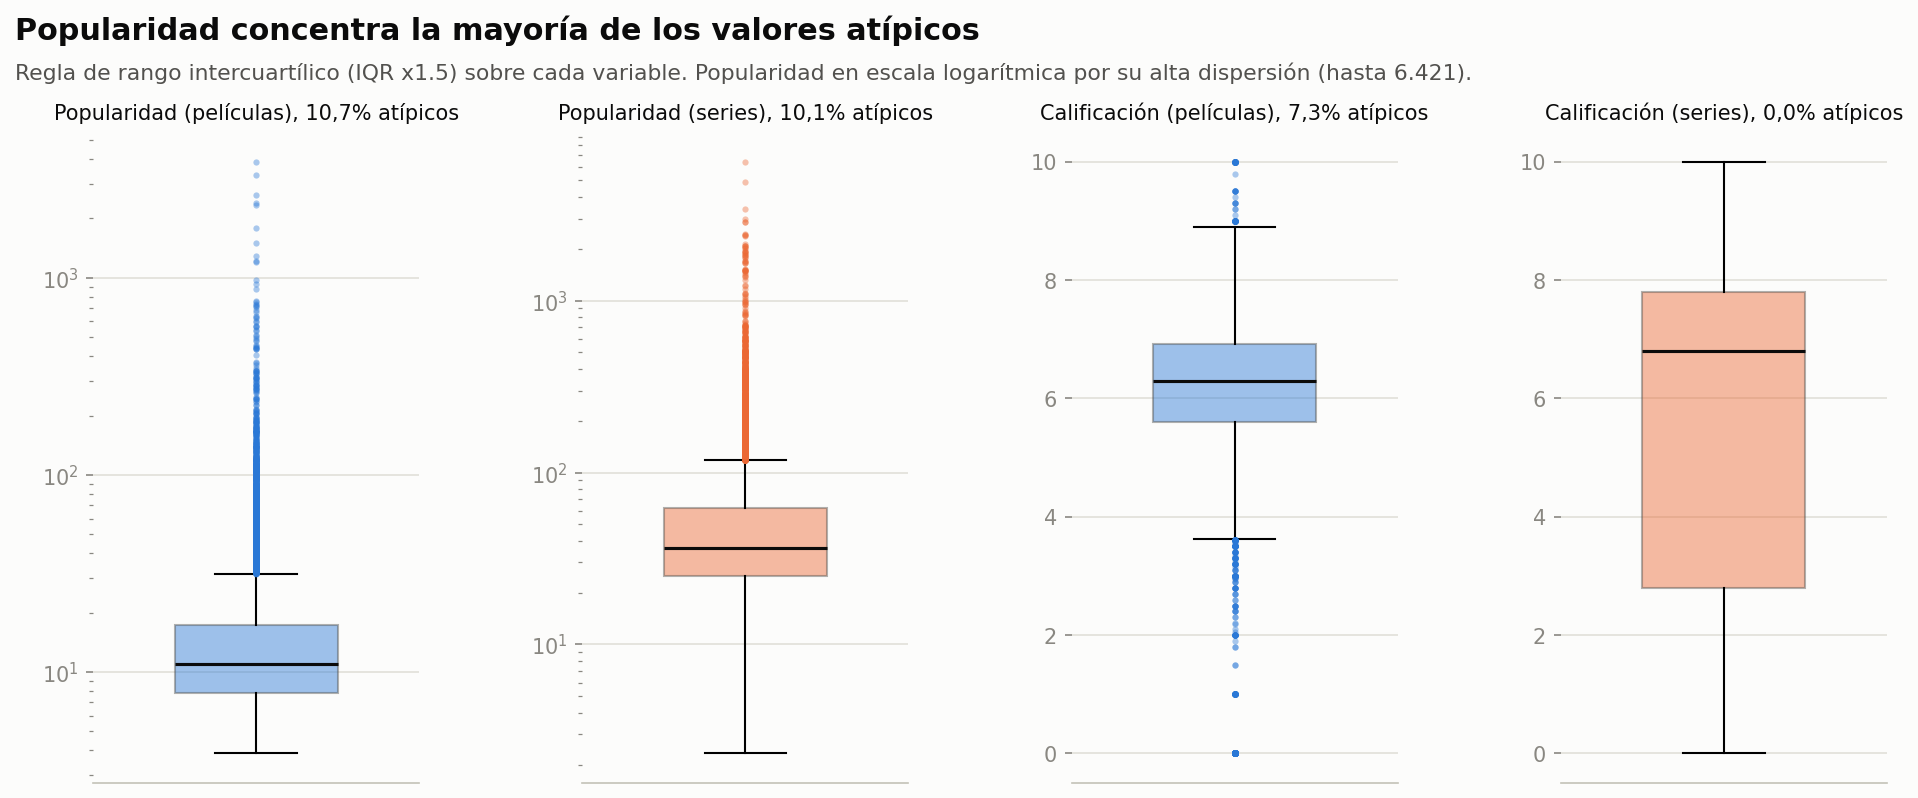

In [35]:
# se calculan y grafican los outliers de popularidad y calificacion
def outlier_boxplot(ax, data, label, color, log=False):
    data = data.dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    pct_atipicos = float(((data < lo) | (data > hi)).mean() * 100)

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    flierprops=dict(markersize=3, markerfacecolor=color, markeredgecolor="none", alpha=0.4))
    for box in bp["boxes"]:
        box.set(facecolor=color, alpha=0.45, edgecolor=INK_SECONDARY)
    for median in bp["medians"]:
        median.set(color=INK_PRIMARY, linewidth=1.5)
    ax.set_xticks([])
    ax.set_title(f"{label}, {pct_atipicos:.1f}% atípicos".replace(".", ","), fontsize=10)
    if log:
        ax.set_yscale("log")
    style_axes(ax, grid_axis="y")


outlier_specs = [
    (movies["popularity"], "Popularidad (películas)", True, PALETTE["blue"]),
    (shows_sin_dup["popularity"], "Popularidad (series)", True, PALETTE["orange"]),
    (movies["vote_average"], "Calificación (películas)", False, PALETTE["blue"]),
    (shows_sin_dup["vote_average"], "Calificación (series)", False, PALETTE["orange"]),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 5.6), dpi=150)
for ax, (data, label, log, color) in zip(axes, outlier_specs):
    outlier_boxplot(ax, data, label, color, log=log)
top = add_title(
    fig,
    "Popularidad concentra la mayoría de los valores atípicos",
    "Regla de rango intercuartílico (IQR x1.5) sobre cada variable. Popularidad en escala logarítmica "
    "por su alta dispersión (hasta 6.421).",
    panel_title_fontsize=10,
)
fig.subplots_adjust(top=top, bottom=0.06, left=0.06, right=0.98, wspace=0.5)
fig.savefig(ASSETS / "v1_outliers_popularidad_calificacion.png")
plt.show()
plt.close(fig)

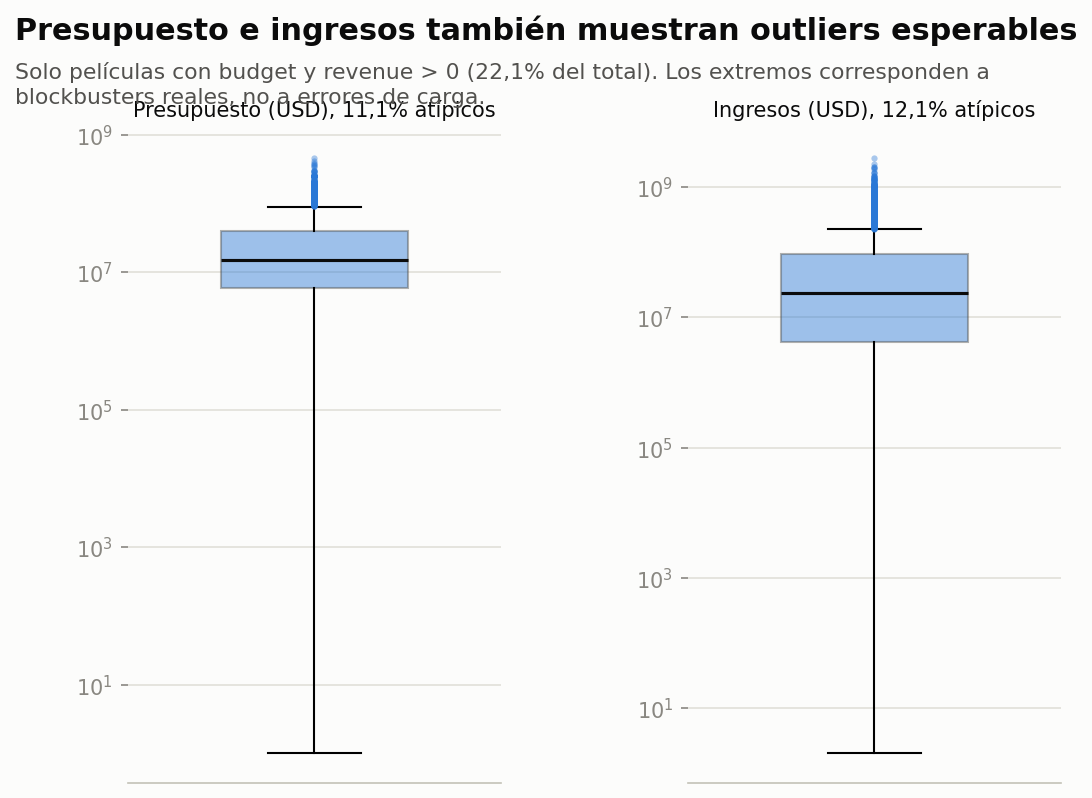

In [36]:
# se grafican los outliers de presupuesto e ingresos (valid_finance ya se definio en la Seccion 2.5)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 5.6), dpi=150)
outlier_boxplot(axes[0], valid_finance["budget"], "Presupuesto (USD)", PALETTE["blue"], log=True)
outlier_boxplot(axes[1], valid_finance["revenue"], "Ingresos (USD)", PALETTE["blue"], log=True)
top = add_title(
    fig,
    "Presupuesto e ingresos también muestran outliers esperables",
    "Solo películas con budget y revenue > 0 (22,1% del total). Los extremos corresponden a "
    "blockbusters reales, no a errores de carga.",
)
fig.subplots_adjust(top=top, bottom=0.06, left=0.12, right=0.95, wspace=0.5)
fig.savefig(ASSETS / "v2_outliers_finanzas.png")
plt.show()
plt.close(fig)

### 2.12 Decisiones de limpieza aplicadas
- Se deduplican los 9 `show_id` repetidos en series, se conserva la primera aparición de cada uno (difieren solo en `popularity`, ver Sección 2.3, sin que la primera aparición sea sistemáticamente mayor o menor) → quedan 15.991 series.
- Se excluye 2025 de los análisis de tendencia de calificación por año
  (dataset incompleto para ese año).
- `budget`/`revenue` en cero se tratan como dato ausente y no se usan en KPIs
  financieros en esta entrega (ver informe, sección "Alcance").
- `rating` se elimina de ambos datasets (Sección 2.2), ya que coincide 100%
  con `vote_average` y no es la clasificación por edad que su nombre sugiere.
- `duration` se elimina de ambos datasets (Sección 2.4), nula en películas
  y sin variación en series.
- Los valores atípicos de popularidad, calificación, budget y revenue se conservan
  (Sección 2.11), ya que corresponden a casos reales (blockbusters, títulos virales), no a
  errores de carga.
- `genres` y `country` se separan con la función `explode()`, que recorta los espacios que
  deja el split por coma (Sección 2.10), sin eso se duplicarían categorías por un espacio de más.
- `genres` se estandariza para que movies y tv compartan la misma taxonomía (Sección 2.10),
  "Action & Adventure" pasa a "Action, Adventure" y "Sci-Fi & Fantasy" a "Science Fiction, Fantasy"
  (ambas mitades ya existían sueltas en movies), "War & Politics" se funde en "War" ("Politics"
  no existe como género propio en ningún lado del dataset).
- El género "Unknown" se descarta igual que un nulo (Sección 2.10), no describe ningún
  género real, y en un caso era el único valor de `genres` para ese título.

In [37]:
# se aplica la deduplicacion definitiva, se eliminan rating y duration
# se estandariza la taxonomia de generos y se descarta "Unknown" y se arman los subsets sin 2025
movies = movies.drop(columns=["rating", "duration"])
shows = shows.drop(columns=["rating", "duration"])

GENRE_STANDARDIZE = {
    "Action & Adventure": "Action, Adventure",
    "Sci-Fi & Fantasy": "Science Fiction, Fantasy",
    "War & Politics": "War",
}

def estandarizar_generos(serie):
    def fix(g):
        if pd.isna(g):
            return g
        tokens = [p.strip() for p in g.split(",") if p.strip() != "Unknown"]
        partes = [GENRE_STANDARDIZE.get(t, t) for t in tokens]
        return ", ".join(partes) if partes else None
    return serie.apply(fix)

movies["genres"] = estandarizar_generos(movies["genres"])
shows["genres"] = estandarizar_generos(shows["genres"])
shows_clean = shows.drop_duplicates(subset="show_id", keep="first").copy()

# Para tendencias por año de calificación/popularidad, excluir 2025 (incompleto)
movies_full_years = movies[movies["release_year"] <= 2024]
shows_full_years = shows_clean[shows_clean["release_year"] <= 2024]

len(shows_clean)

15991

## 3. KPIs

KPIs del catálogo, de popularidad y de valoración, con el alcance
documentado en el informe (los KPIs financieros y de clasificación etaria
quedan fuera de esta entrega, con su justificación de calidad de datos).

In [38]:
# se calculan los KPIs iniciales del catalogo
kpis = {}
kpis["total_contenidos"] = int(len(movies) + len(shows_clean))
kpis["total_peliculas"] = int(len(movies))
kpis["total_series"] = int(len(shows_clean))

countries_all = pd.concat([explode(movies, "country"), explode(shows_clean, "country")])
languages_all = pd.concat([movies["language"], shows_clean["language"]]).dropna()
genres_all = pd.concat([explode(movies, "genres"), explode(shows_clean, "genres")])

kpis["n_paises"] = int(countries_all.nunique())
kpis["n_idiomas"] = int(languages_all.nunique())
kpis["n_generos"] = int(genres_all.nunique())
kpis["popularidad_promedio_movies"] = round(float(movies["popularity"].mean()), 2)
kpis["popularidad_promedio_tv"] = round(float(shows_clean["popularity"].mean()), 2)
kpis["calificacion_promedio_movies"] = round(float(movies["vote_average"].mean()), 2)
kpis["calificacion_promedio_tv"] = round(float(shows_clean["vote_average"].mean()), 2)

# vote_count >= 10 justificado en la Seccion 2.7
corr_m = movies.loc[movies["vote_count"] >= 10, ["popularity", "vote_average"]].corr().iloc[0, 1]
corr_t = shows_clean.loc[shows_clean["vote_count"] >= 10, ["popularity", "vote_average"]].corr().iloc[0, 1]
kpis["correlacion_popularidad_calificacion_movies"] = round(float(corr_m), 3)
kpis["correlacion_popularidad_calificacion_tv"] = round(float(corr_t), 3)

kpis 

{'total_contenidos': 31991,
 'total_peliculas': 16000,
 'total_series': 15991,
 'n_paises': 147,
 'n_idiomas': 83,
 'n_generos': 24,
 'popularidad_promedio_movies': 20.38,
 'popularidad_promedio_tv': 64.88,
 'calificacion_promedio_movies': 5.96,
 'calificacion_promedio_tv': 5.42,
 'correlacion_popularidad_calificacion_movies': 0.088,
 'correlacion_popularidad_calificacion_tv': -0.022}

## 4. Visualizaciones

Cada gráfico responde a una pregunta de negocio concreta. Se aplica un color por rol (un solo tono para magnitud, paleta categórica
fija para identidad) y jerarquía tipográfica clara.

### 4.1 Drama y Comedia dominan en ambos formatos, el resto del top 10 no
Pregunta de negocio. ¿qué géneros predominan?

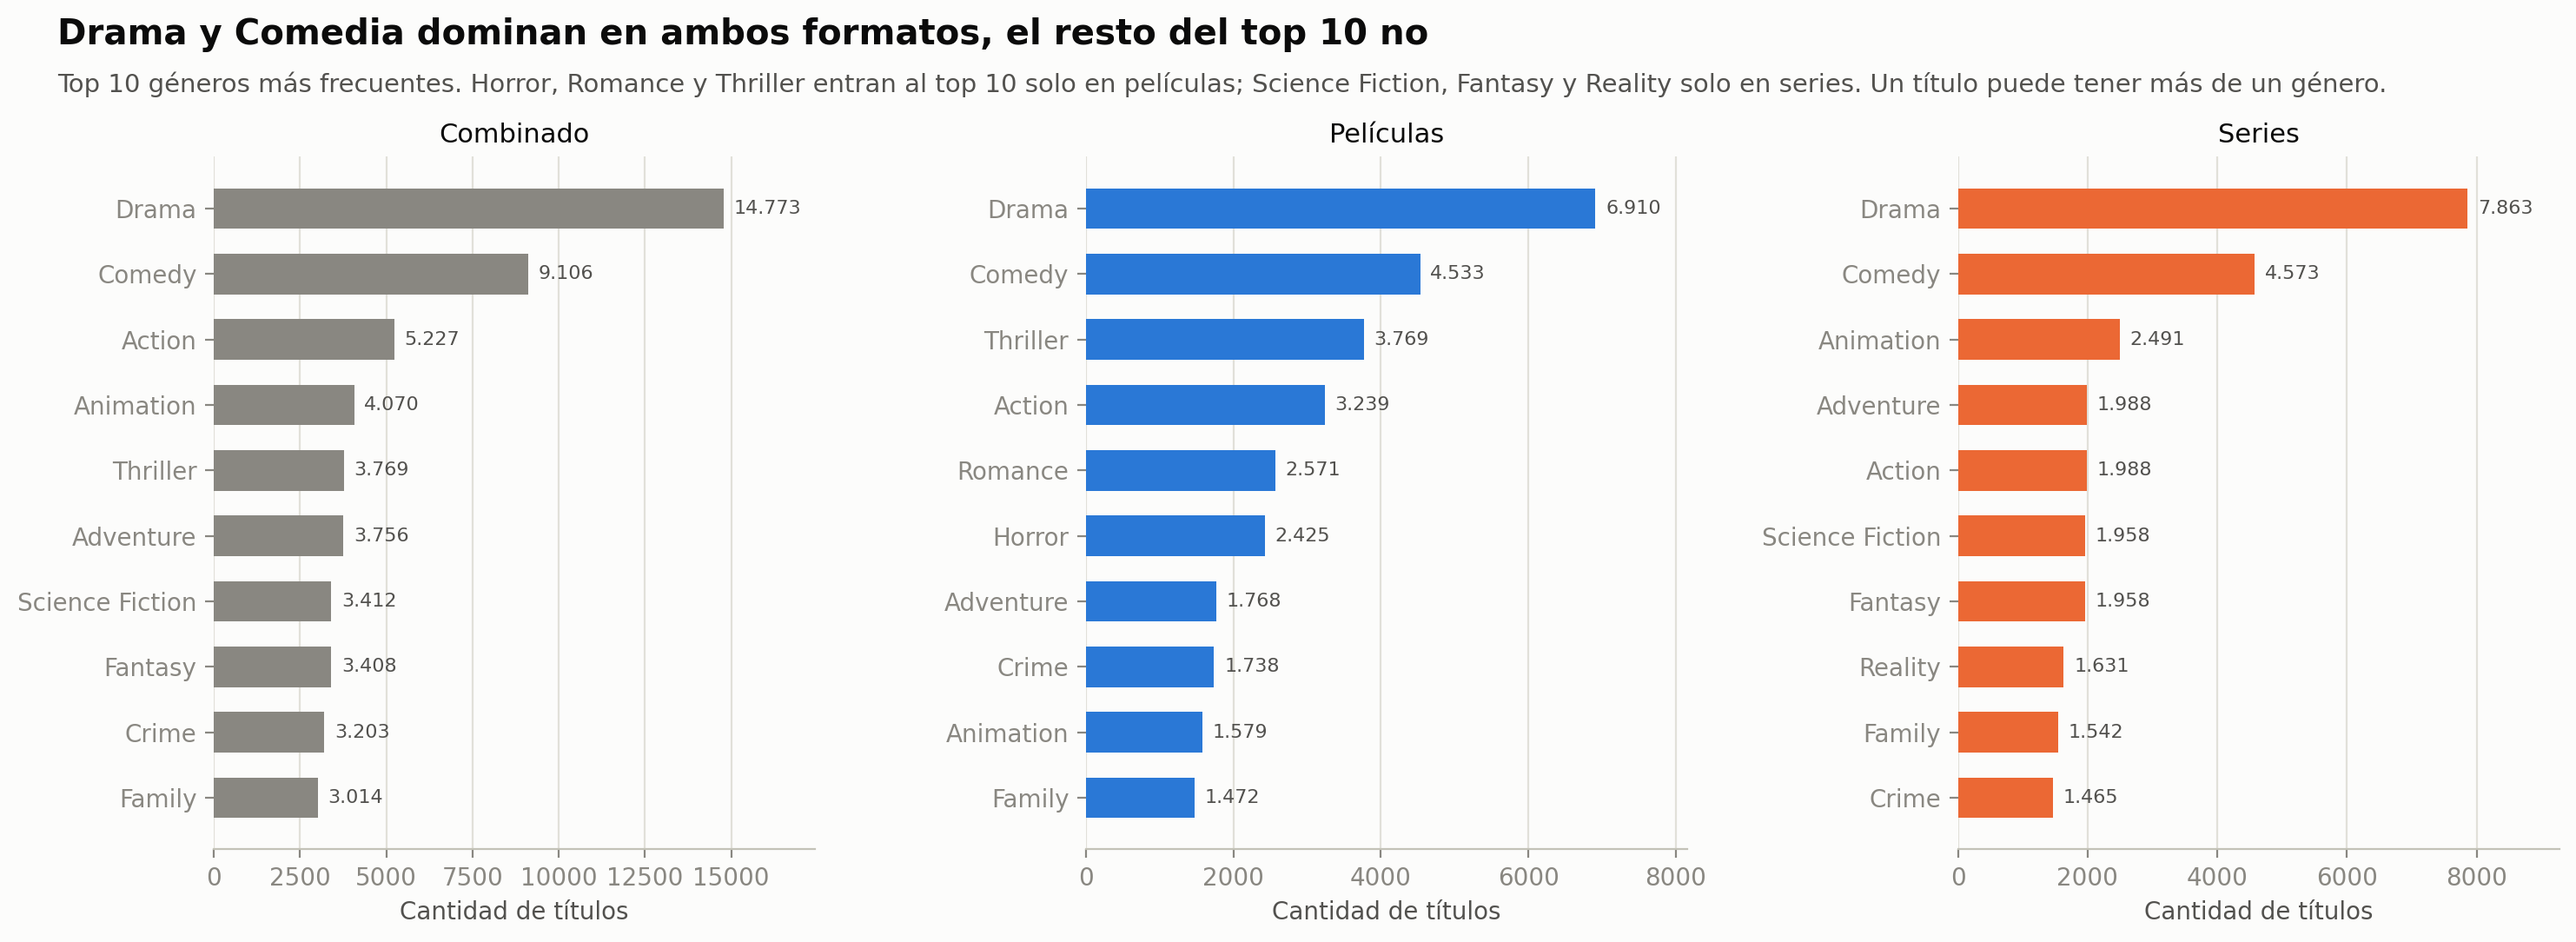

In [39]:
# top 10 generos mas frecuentes, combinado y por tipo
genres_movies = explode(movies, "genres").value_counts()
genres_tv = explode(shows_clean, "genres").value_counts()
genres_combo = genres_all.value_counts()

genre_specs = [
    (genres_combo.head(10).sort_values(), "Combinado", INK_MUTED),
    (genres_movies.head(10).sort_values(), "Películas", PALETTE["blue"]),
    (genres_tv.head(10).sort_values(), "Series", PALETTE["orange"]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), dpi=200)
for ax, (data, label, color) in zip(axes, genre_specs):
    bars = ax.barh(data.index, data.values, color=color, height=0.62, zorder=3)
    ax.set_xlim(0, data.values.max() * 1.18)
    style_axes(ax, grid_axis="x")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Cantidad de títulos")
    for b, v in zip(bars, data.values):
        ax.text(v + data.values.max() * 0.02, b.get_y() + b.get_height() / 2, f"{v:,}".replace(",", "."),
                va="center", ha="left", fontsize=8, color=INK_SECONDARY)
top = add_title(
    fig,
    "Drama y Comedia dominan en ambos formatos, el resto del top 10 no",
    "Top 10 géneros más frecuentes. Horror, Romance y Thriller entran al top 10 solo en "
    "películas; Science Fiction, Fantasy y Reality solo en series. Un título puede tener "
    "más de un género.",
    panel_title_fontsize=11,
)
fig.subplots_adjust(top=top, bottom=0.12, left=0.08, right=0.98, wspace=0.45)
fig.savefig(ASSETS / "v3_top_generos.png")
plt.show()
plt.close(fig)

### 4.2 Ningún género por sí solo domina el catálogo

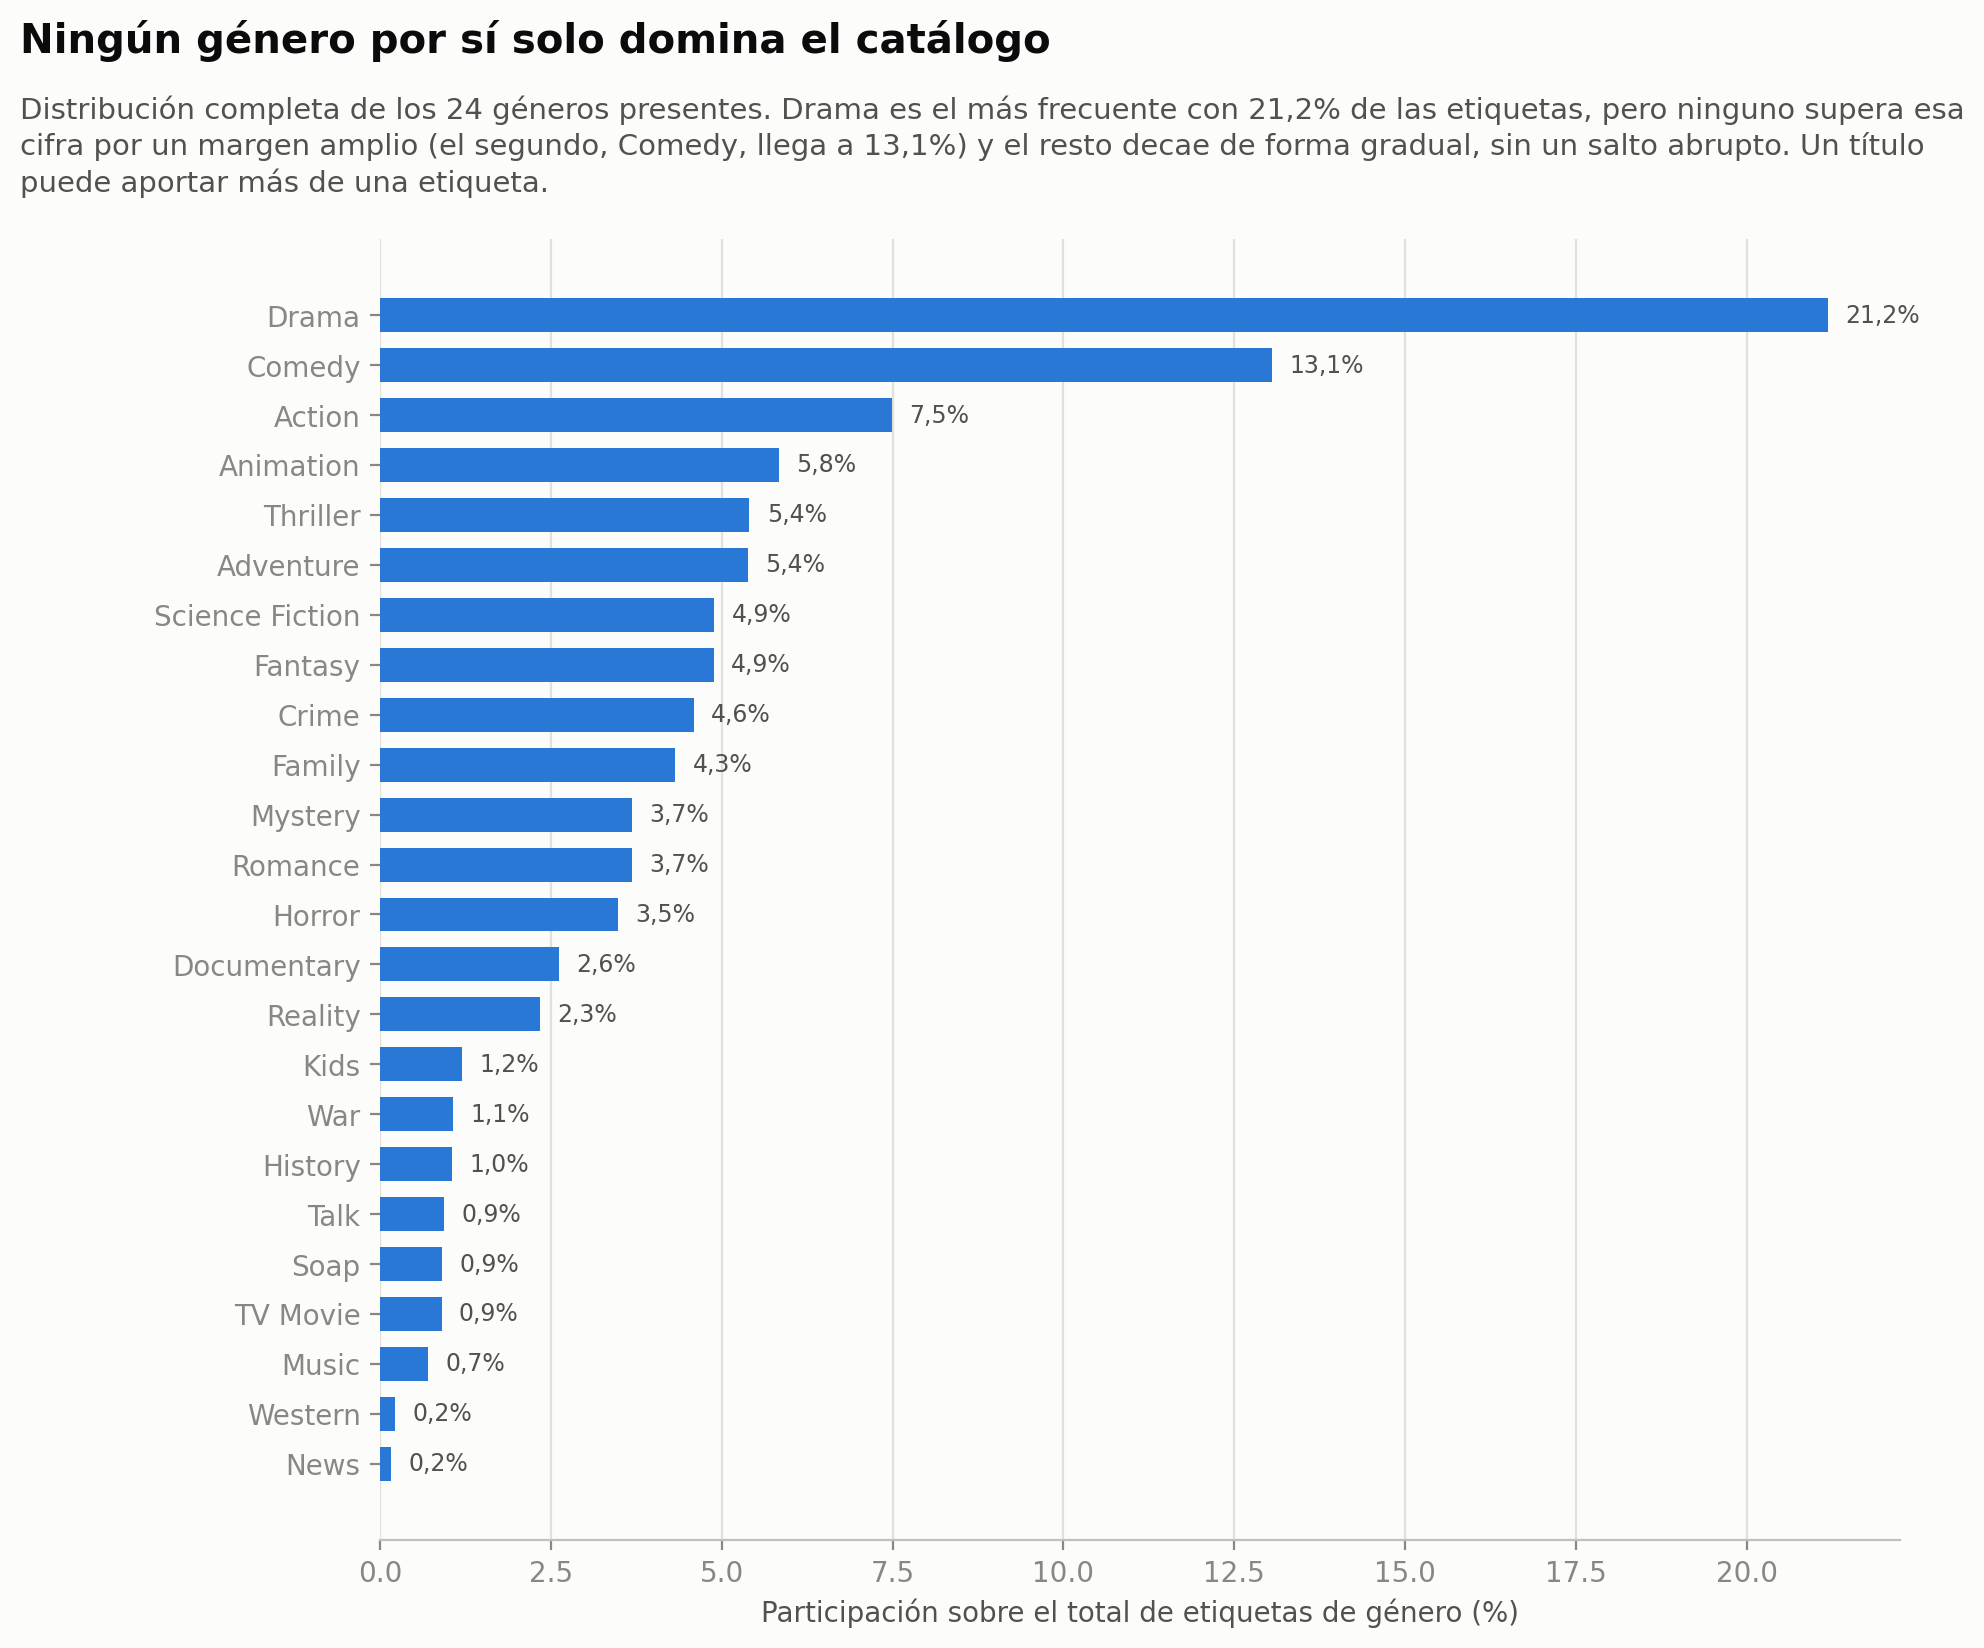

In [40]:
# distribucion de todos los generos, no solo el top 10 (Seccion 4.1)
genre_counts = genres_all.value_counts()
genre_pct = (genre_counts / genre_counts.sum() * 100).sort_values()
top1_pct = genre_pct.iloc[-1]
top2_pct = genre_pct.iloc[-2]
top1_pct_fmt = f"{top1_pct:.1f}".replace(".", ",")
top2_pct_fmt = f"{top2_pct:.1f}".replace(".", ",")

fig, ax = plt.subplots(figsize=(10, 8.4), dpi=200)
bars = ax.barh(genre_pct.index, genre_pct.values, color=PALETTE["blue"], height=0.68, zorder=3)
style_axes(ax, grid_axis="x")
ax.set_xlabel("Participación sobre el total de etiquetas de género (%)")
for b, v in zip(bars, genre_pct.values):
    ax.text(v + genre_pct.max() * 0.012, b.get_y() + b.get_height() / 2,
             f"{v:.1f}".replace(".", ",") + "%", va="center", ha="left", fontsize=8.5, color=INK_SECONDARY)
top = add_title(
    fig,
    "Ningún género por sí solo domina el catálogo",
    f"Distribución completa de los {len(genre_counts)} géneros presentes. Drama es el más frecuente "
    f"con {top1_pct_fmt}% de las etiquetas, pero ninguno supera esa cifra por un margen amplio "
    f"(el segundo, Comedy, llega a {top2_pct_fmt}%) y el resto decae de forma gradual, sin un salto "
    "abrupto. Un título puede aportar más de una etiqueta.",
)
fig.subplots_adjust(top=top, bottom=0.07, left=0.20, right=0.96)
fig.savefig(ASSETS / "v4_distribucion_generos.png")
plt.show()
plt.close(fig)

### 4.3 Estados Unidos produce más contenido que los siguientes 4 países del top 10 combinados
Pregunta de negocio. ¿qué países producen más contenido?

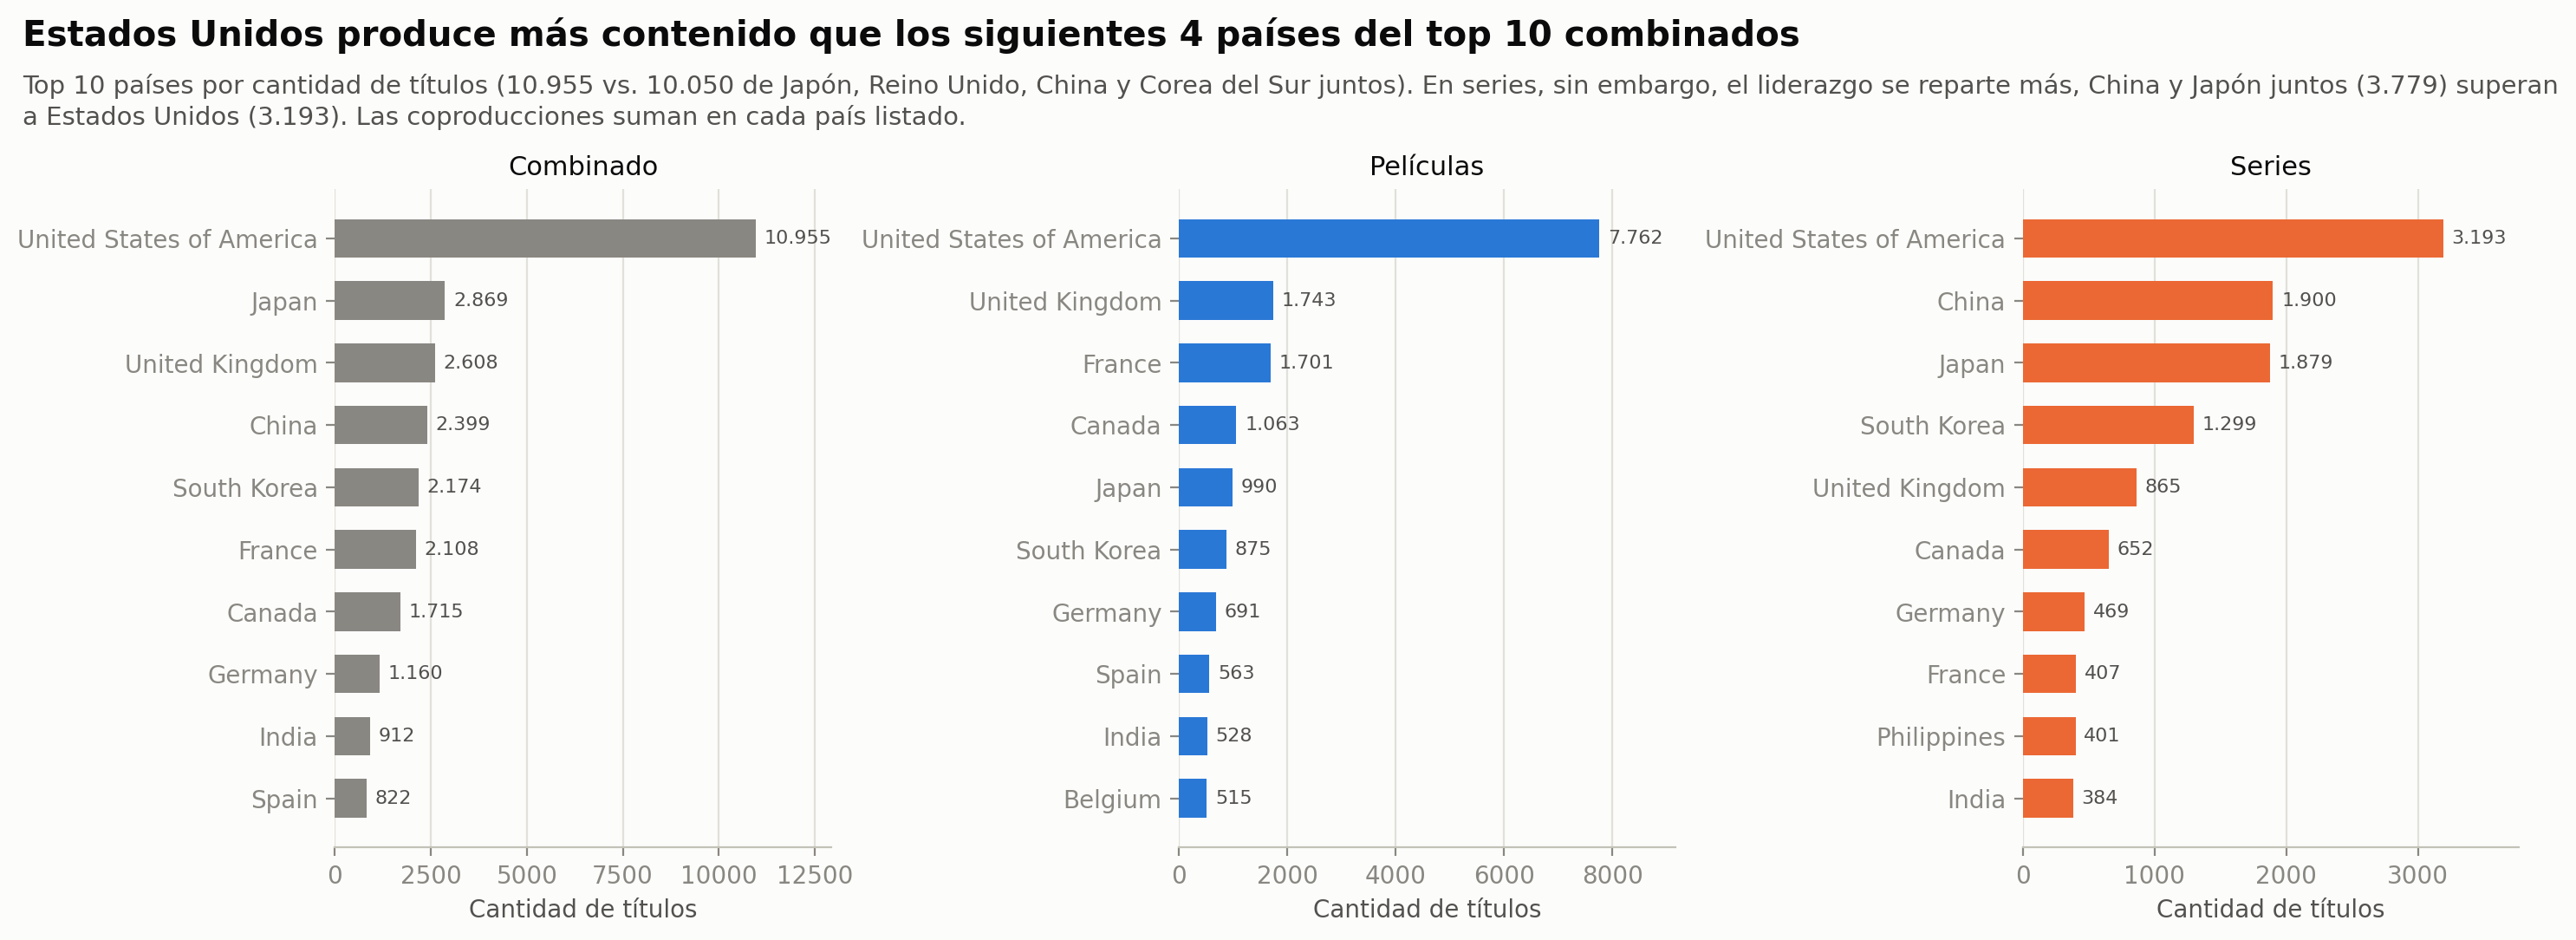

In [41]:
# top 10 paises productores, combinado y por tipo
countries_movies = explode(movies, "country").value_counts()
countries_tv = explode(shows_clean, "country").value_counts()
countries_combo = countries_all.value_counts()

# la cabecera se apoya en el patron mas robusto del grafico (el liderazgo de EE. UU.), no
# en el pais con el cambio de ranking mas llamativo, que es un dato secundario y mas facil
# de leer como sesgado hacia un pais en particular
top5_combo = countries_combo.head(5)
us_combo_fmt = f"{top5_combo.iloc[0]:,}".replace(",", ".")
next4_combo_fmt = f"{top5_combo.iloc[1:5].sum():,}".replace(",", ".")
us_series_fmt = f"{countries_tv['United States of America']:,}".replace(",", ".")
china_japan_series_fmt = f"{countries_tv['China'] + countries_tv['Japan']:,}".replace(",", ".")

country_specs = [
    (countries_combo.head(10).sort_values(), "Combinado", INK_MUTED),
    (countries_movies.head(10).sort_values(), "Películas", PALETTE["blue"]),
    (countries_tv.head(10).sort_values(), "Series", PALETTE["orange"]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), dpi=200)
for ax, (data, label, color) in zip(axes, country_specs):
    bars = ax.barh(data.index, data.values, color=color, height=0.62, zorder=3)
    ax.set_xlim(0, data.values.max() * 1.18)
    style_axes(ax, grid_axis="x")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Cantidad de títulos")
    for b, v in zip(bars, data.values):
        ax.text(v + data.values.max() * 0.02, b.get_y() + b.get_height() / 2, f"{v:,}".replace(",", "."),
                va="center", ha="left", fontsize=8, color=INK_SECONDARY)
top = add_title(
    fig,
    "Estados Unidos produce más contenido que los siguientes 4 países del top 10 combinados",
    f"Top 10 países por cantidad de títulos ({us_combo_fmt} vs. {next4_combo_fmt} de Japón, Reino Unido, "
    f"China y Corea del Sur juntos). En series, sin embargo, el liderazgo se reparte más, China y Japón "
    f"juntos ({china_japan_series_fmt}) superan a Estados Unidos ({us_series_fmt}). Las coproducciones "
    "suman en cada país listado.",
    panel_title_fontsize=11,
)
fig.subplots_adjust(top=top, bottom=0.12, left=0.14, right=0.98, wspace=0.7)
fig.savefig(ASSETS / "v5_top_paises.png")
plt.show()
plt.close(fig)

### 4.4 La popularidad no depende de la calificación
Pregunta de negocio. ¿existe relación entre popularidad y calificación?

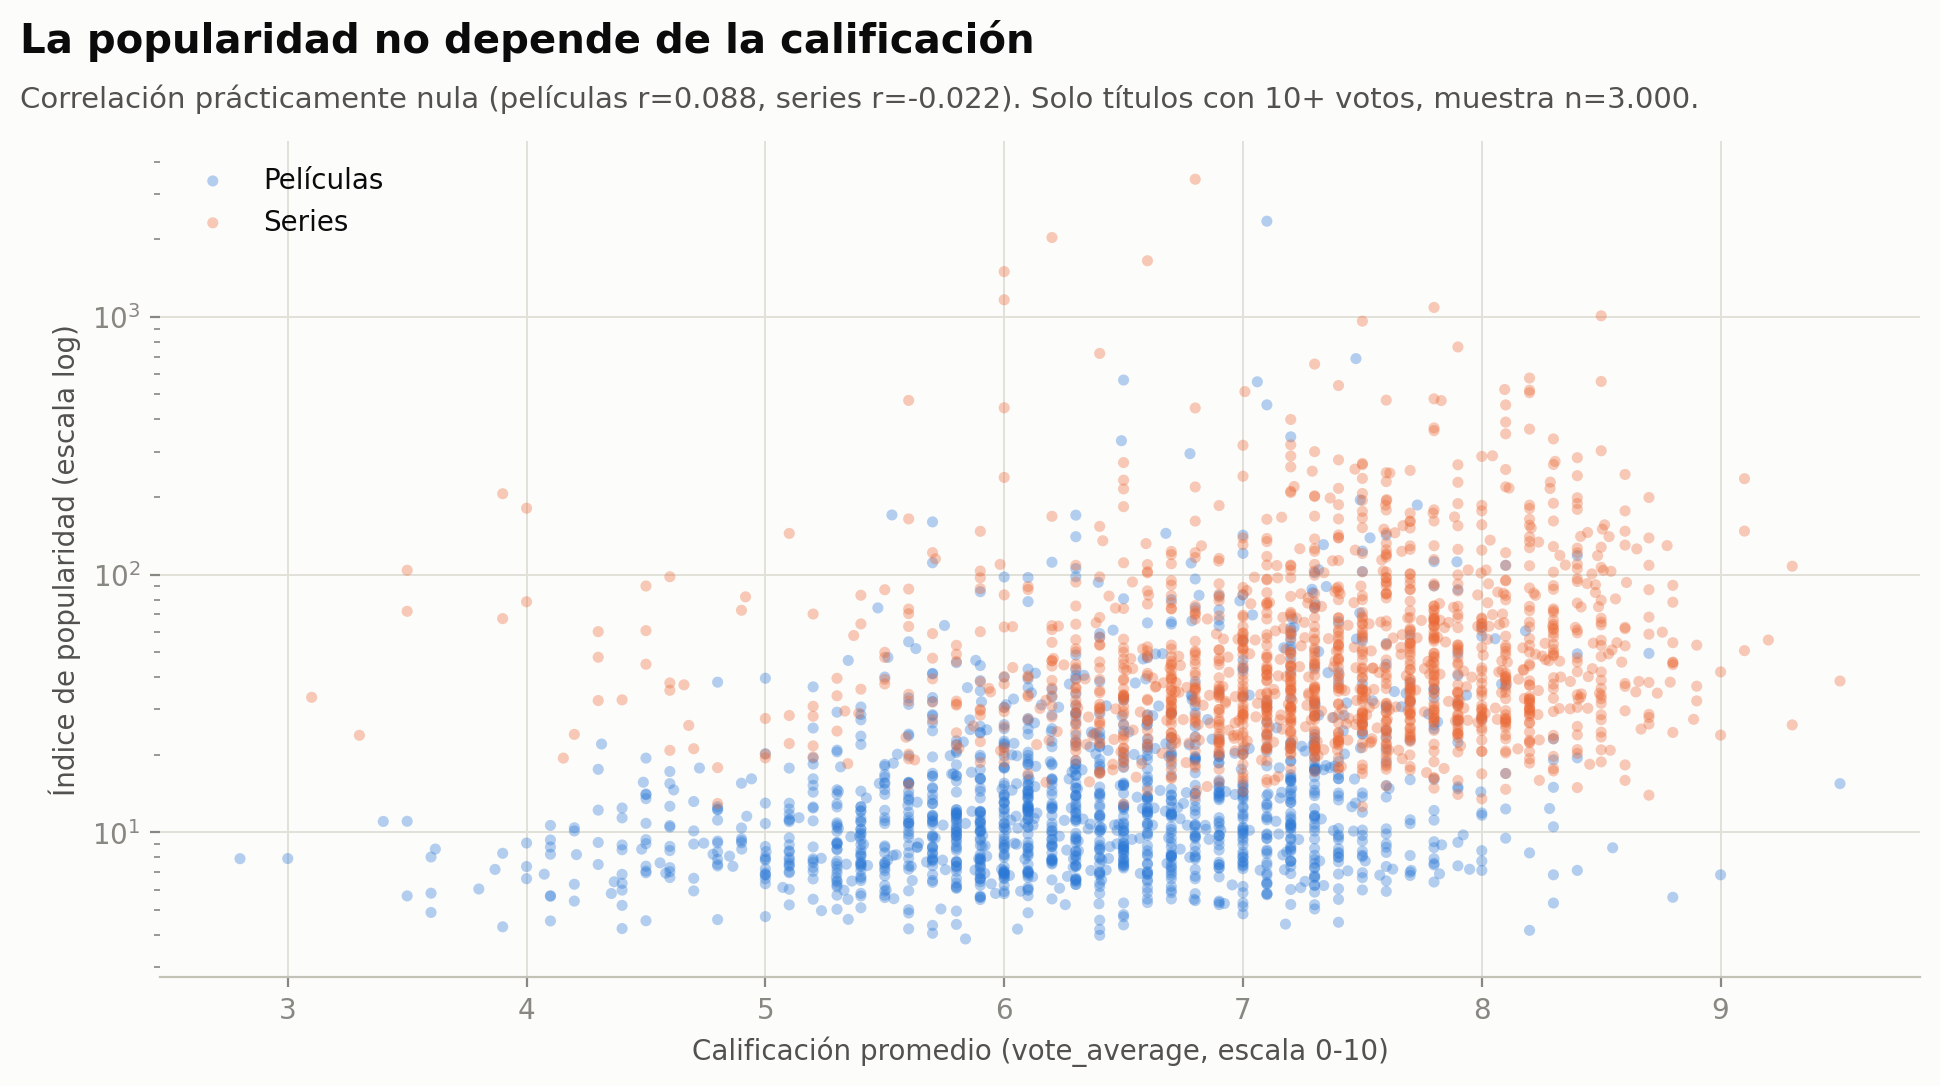

In [42]:
# Solo titulos con 10+ votos (justificacion en la Seccion 2.7); se muestrea a
# 1.500 puntos por grupo para que el grafico no quede sobrecargado de puntos.
m_s = movies[movies["vote_count"] >= 10]
m_s = m_s.sample(1500, random_state=42) if len(m_s) > 1500 else m_s
t_s = shows_clean[shows_clean["vote_count"] >= 10]
t_s = t_s.sample(1500, random_state=42) if len(t_s) > 1500 else t_s

fig, ax = plt.subplots(figsize=(10, 5.6), dpi=200)
ax.scatter(m_s["vote_average"], m_s["popularity"], s=16, color=PALETTE["blue"], alpha=0.35,
           edgecolors="none", label="Películas", zorder=3)
ax.scatter(t_s["vote_average"], t_s["popularity"], s=16, color=PALETTE["orange"], alpha=0.35,
           edgecolors="none", label="Series", zorder=3)
ax.set_yscale("log")
style_axes(ax, grid_axis="both")
ax.grid(axis="both", color=GRID, linewidth=0.7)
ax.set_xlabel("Calificación promedio (vote_average, escala 0-10)")
ax.set_ylabel("Índice de popularidad (escala log)")
ax.legend(frameon=False, loc="upper left", fontsize=10)
top = add_title(
    fig,
    "La popularidad no depende de la calificación",
    f"Correlación prácticamente nula (películas r={kpis['correlacion_popularidad_calificacion_movies']}, "
    f"series r={kpis['correlacion_popularidad_calificacion_tv']}). Solo títulos con 10+ votos, muestra n=3.000.",
)
fig.subplots_adjust(top=top, bottom=0.12, left=0.09, right=0.97)
fig.savefig(ASSETS / "v6_dispersion_popularidad_calificacion.png")
plt.show()
plt.close(fig)

### 4.5 Programas de conversación y telenovelas dominan el top 10
Pregunta de negocio. ¿qué contenidos presentan mayor popularidad?

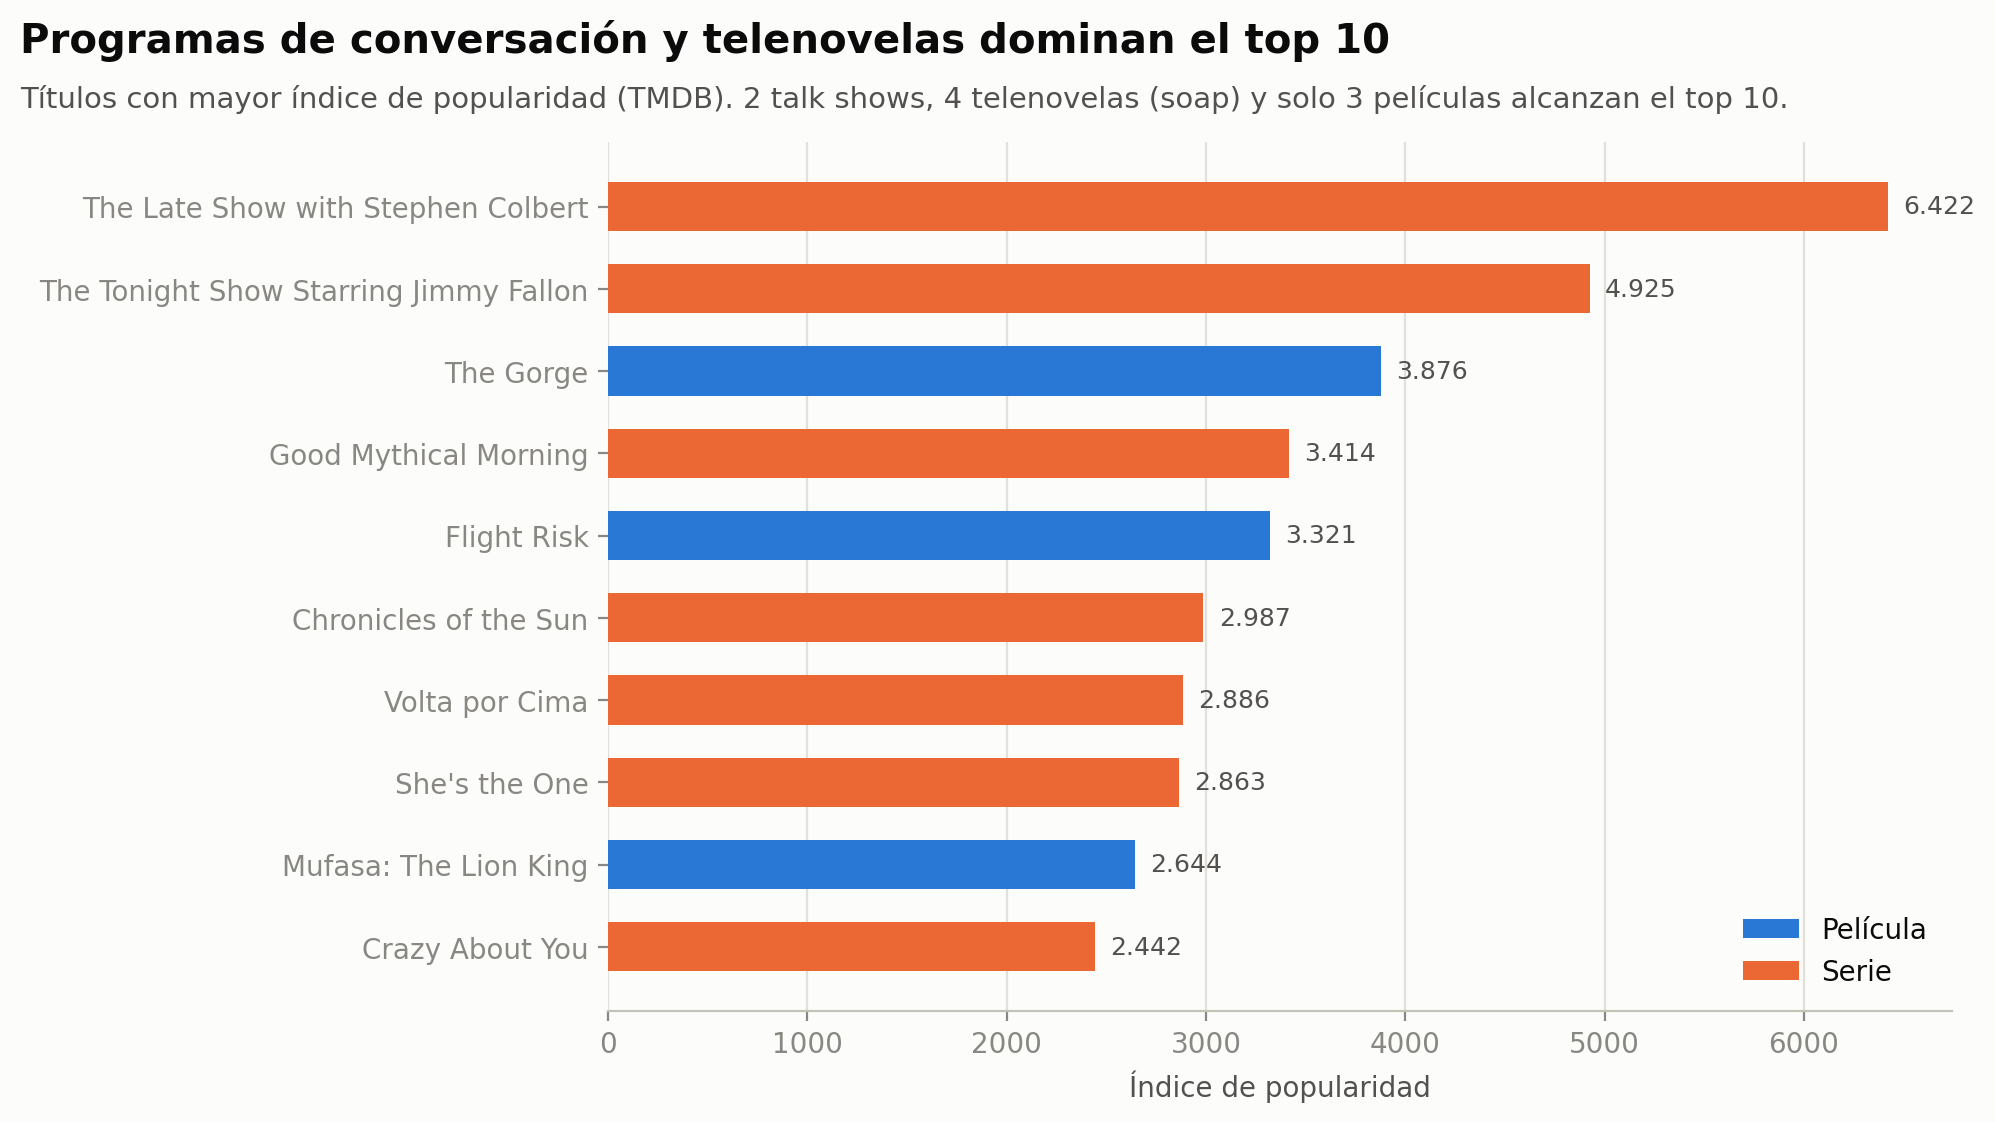

In [43]:
# top 10 contenidos mas populares
combo = pd.concat([
    movies[["title", "type", "popularity"]],
    shows_clean[["title", "type", "popularity"]],
])
top10_pop = combo.sort_values("popularity", ascending=False).head(10).iloc[::-1]
colors = [PALETTE["blue"] if t == "Movie" else PALETTE["orange"] for t in top10_pop["type"]]

fig, ax = plt.subplots(figsize=(10.5, 5.8), dpi=200)
bars = ax.barh(top10_pop["title"], top10_pop["popularity"], color=colors, height=0.6, zorder=3)
style_axes(ax, grid_axis="x")
ax.set_xlabel("Índice de popularidad")
for b, v in zip(bars, top10_pop["popularity"]):
    ax.text(v + top10_pop["popularity"].max() * 0.012, b.get_y() + b.get_height() / 2,
            f"{v:,.0f}".replace(",", "."), va="center", ha="left", fontsize=9, color=INK_SECONDARY)
legend_pelicula_serie(ax, bars, colors)
top = add_title(
    fig,
    "Programas de conversación y telenovelas dominan el top 10",
    "Títulos con mayor índice de popularidad (TMDB). 2 talk shows, 4 telenovelas (soap) "
    "y solo 3 películas alcanzan el top 10.",
)
fig.subplots_adjust(top=top, bottom=0.12, left=0.30, right=0.94)
fig.savefig(ASSETS / "v7_top10_populares.png")
plt.show()
plt.close(fig)

### 4.6 Soap y Talk son los géneros con mayor popularidad promedio
Pregunta de negocio. ¿qué géneros concentran mayor popularidad?

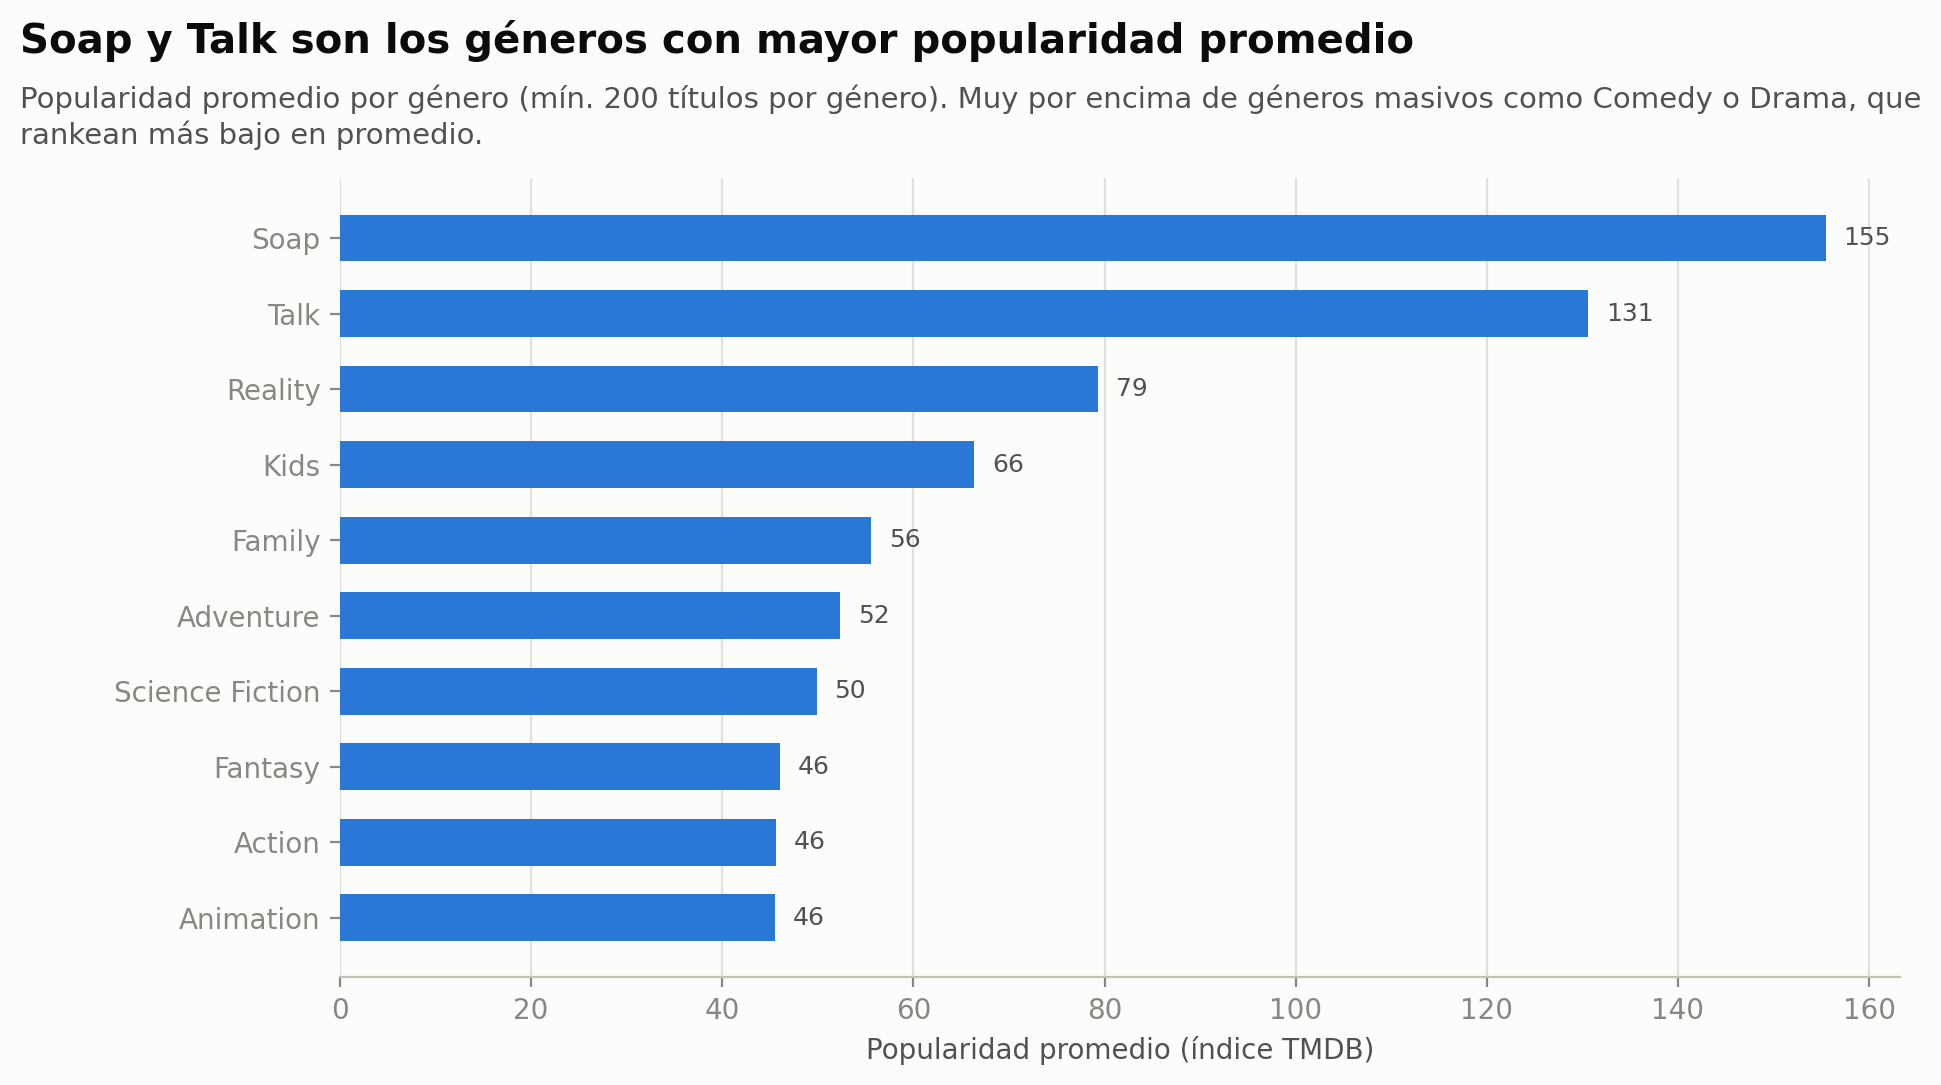

In [44]:
# popularidad promedio por genero
def genre_metric(df, metric):
    g = df[["genres", metric]].dropna().assign(genres=lambda d: d["genres"].str.split(","))
    g = g.explode("genres")
    g["genres"] = g["genres"].str.strip()
    return g

gpop = pd.concat([genre_metric(movies, "popularity"), genre_metric(shows_clean, "popularity")])
gstats = gpop.groupby("genres")["popularity"].agg(["mean", "count"])
gstats = gstats[gstats["count"] >= 200].sort_values("mean").tail(10)

fig, ax = plt.subplots(figsize=(10, 5.6), dpi=200)
bars = ax.barh(gstats.index, gstats["mean"], color=PALETTE["blue"], height=0.62, zorder=3)
style_axes(ax, grid_axis="x")
ax.set_xlabel("Popularidad promedio (índice TMDB)")
for b, v in zip(bars, gstats["mean"]):
    ax.text(v + gstats["mean"].max() * 0.012, b.get_y() + b.get_height() / 2, f"{v:,.0f}".replace(",", "."),
            va="center", ha="left", fontsize=9, color=INK_SECONDARY)
top = add_title(
    fig,
    "Soap y Talk son los géneros con mayor popularidad promedio",
    "Popularidad promedio por género (mín. 200 títulos por género). Muy por encima de géneros "
    "masivos como Comedy o Drama, que rankean más bajo en promedio.",
)
fig.subplots_adjust(top=top, bottom=0.12, left=0.18, right=0.96)
fig.savefig(ASSETS / "v8_popularidad_por_genero.png")
plt.show()
plt.close(fig)

### 4.7 Las series mejoraron su calificación, las películas se mantienen estables
Pregunta de negocio. ¿ha cambiado la calificación de los contenidos a lo largo del tiempo?

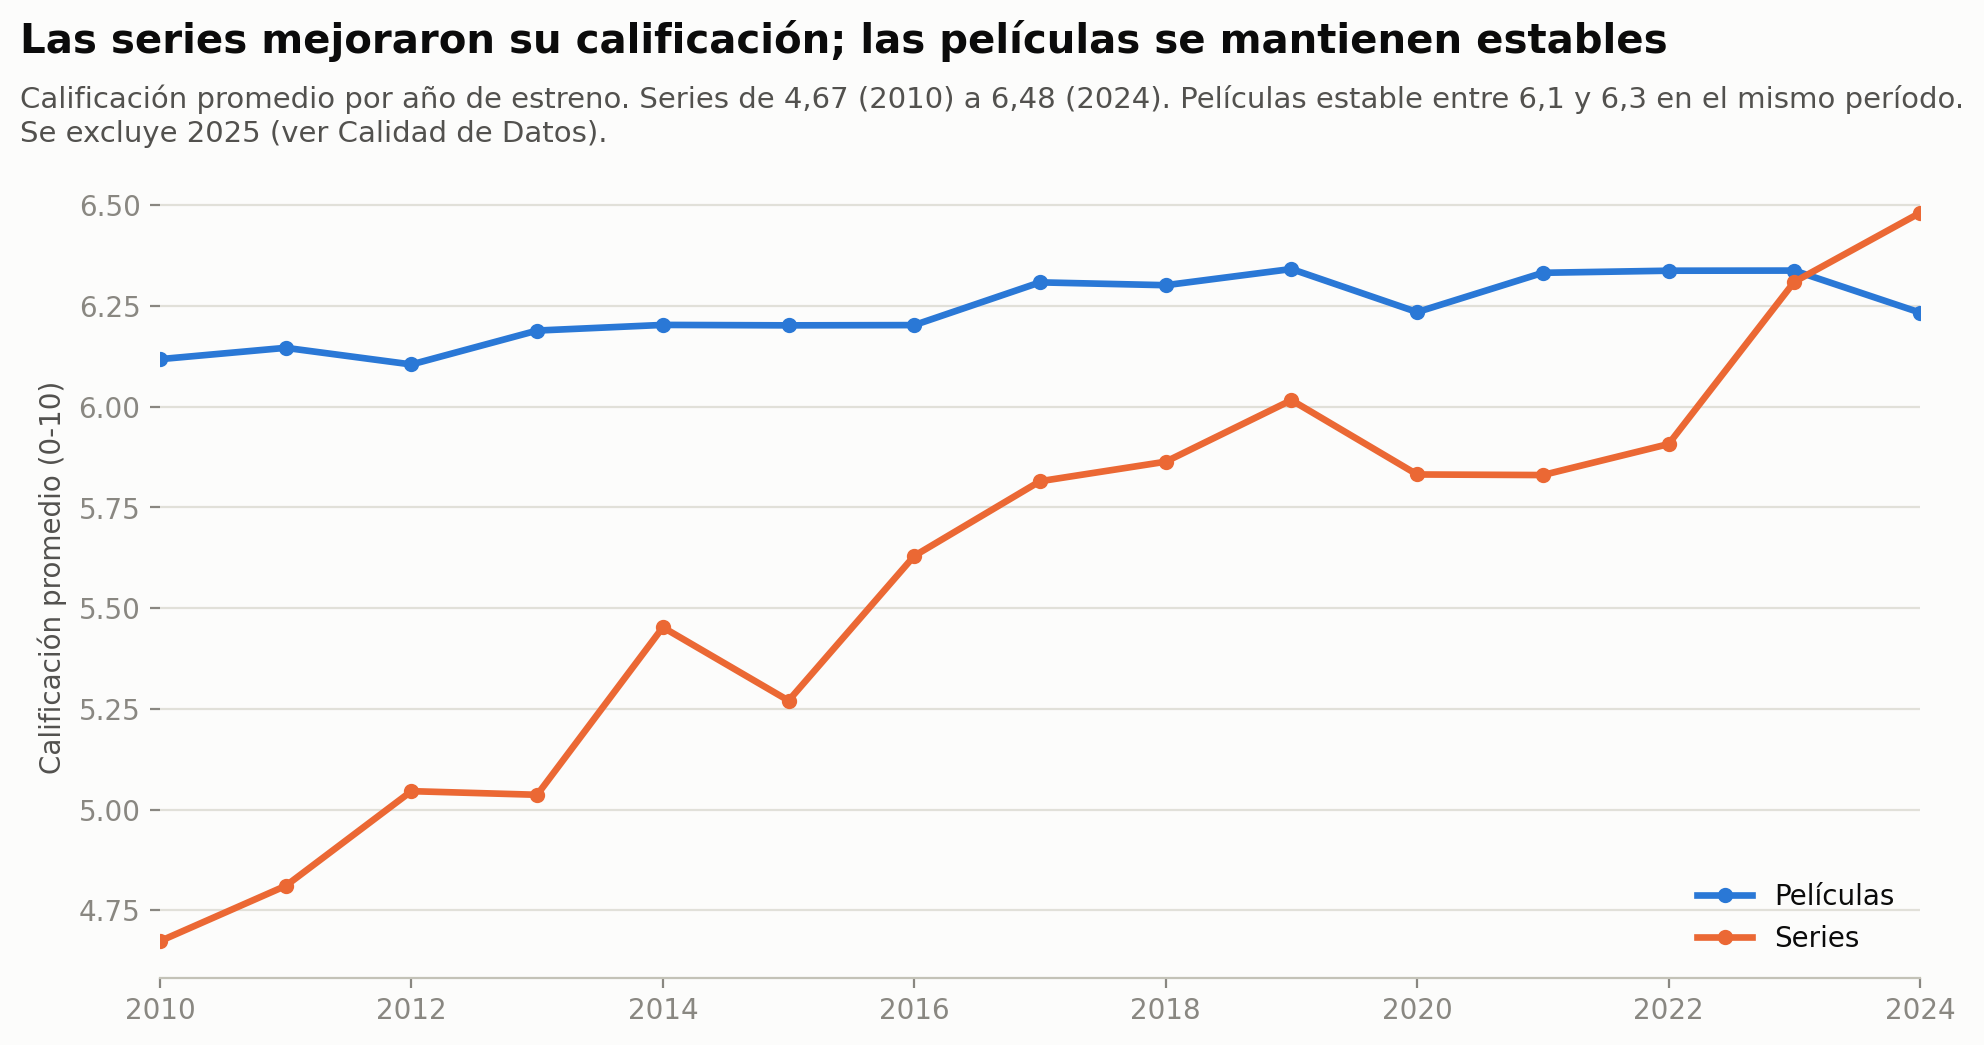

In [45]:
# calificacion promedio por año de estreno
rating_m = movies_full_years.groupby("release_year")["vote_average"].mean()
rating_t = shows_full_years.groupby("release_year")["vote_average"].mean()

fig, ax = plt.subplots(figsize=(10, 5.6), dpi=200)
ax.plot(rating_m.index, rating_m.values, color=PALETTE["blue"], linewidth=2.4, marker="o", markersize=4.5, label="Películas")
ax.plot(rating_t.index, rating_t.values, color=PALETTE["orange"], linewidth=2.4, marker="o", markersize=4.5, label="Series")
style_axes(ax, grid_axis="y")
ax.set_xlim(2010, 2024)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.set_ylabel("Calificación promedio (0-10)")
ax.legend(frameon=False, loc="lower right", fontsize=10)
top = add_title(
    fig,
    "Las series mejoraron su calificación; las películas se mantienen estables",
    "Calificación promedio por año de estreno. Series de 4,67 (2010) a 6,48 (2024). "
    "Películas estable entre 6,1 y 6,3 en el mismo período. Se excluye 2025 (ver Calidad de Datos).",
)
fig.subplots_adjust(top=top, bottom=0.12, left=0.09, right=0.97)
fig.savefig(ASSETS / "v9_calificacion_por_anio.png")
plt.show()
plt.close(fig)

### 4.8 El catálogo está distribuido de forma perfectamente uniforme
Pregunta de negocio. ¿cómo ha evolucionado el catálogo? Este es el gráfico que expone el
hallazgo descrito en la Sección 2.6, no una tendencia de crecimiento, sino evidencia de
una muestra curada.

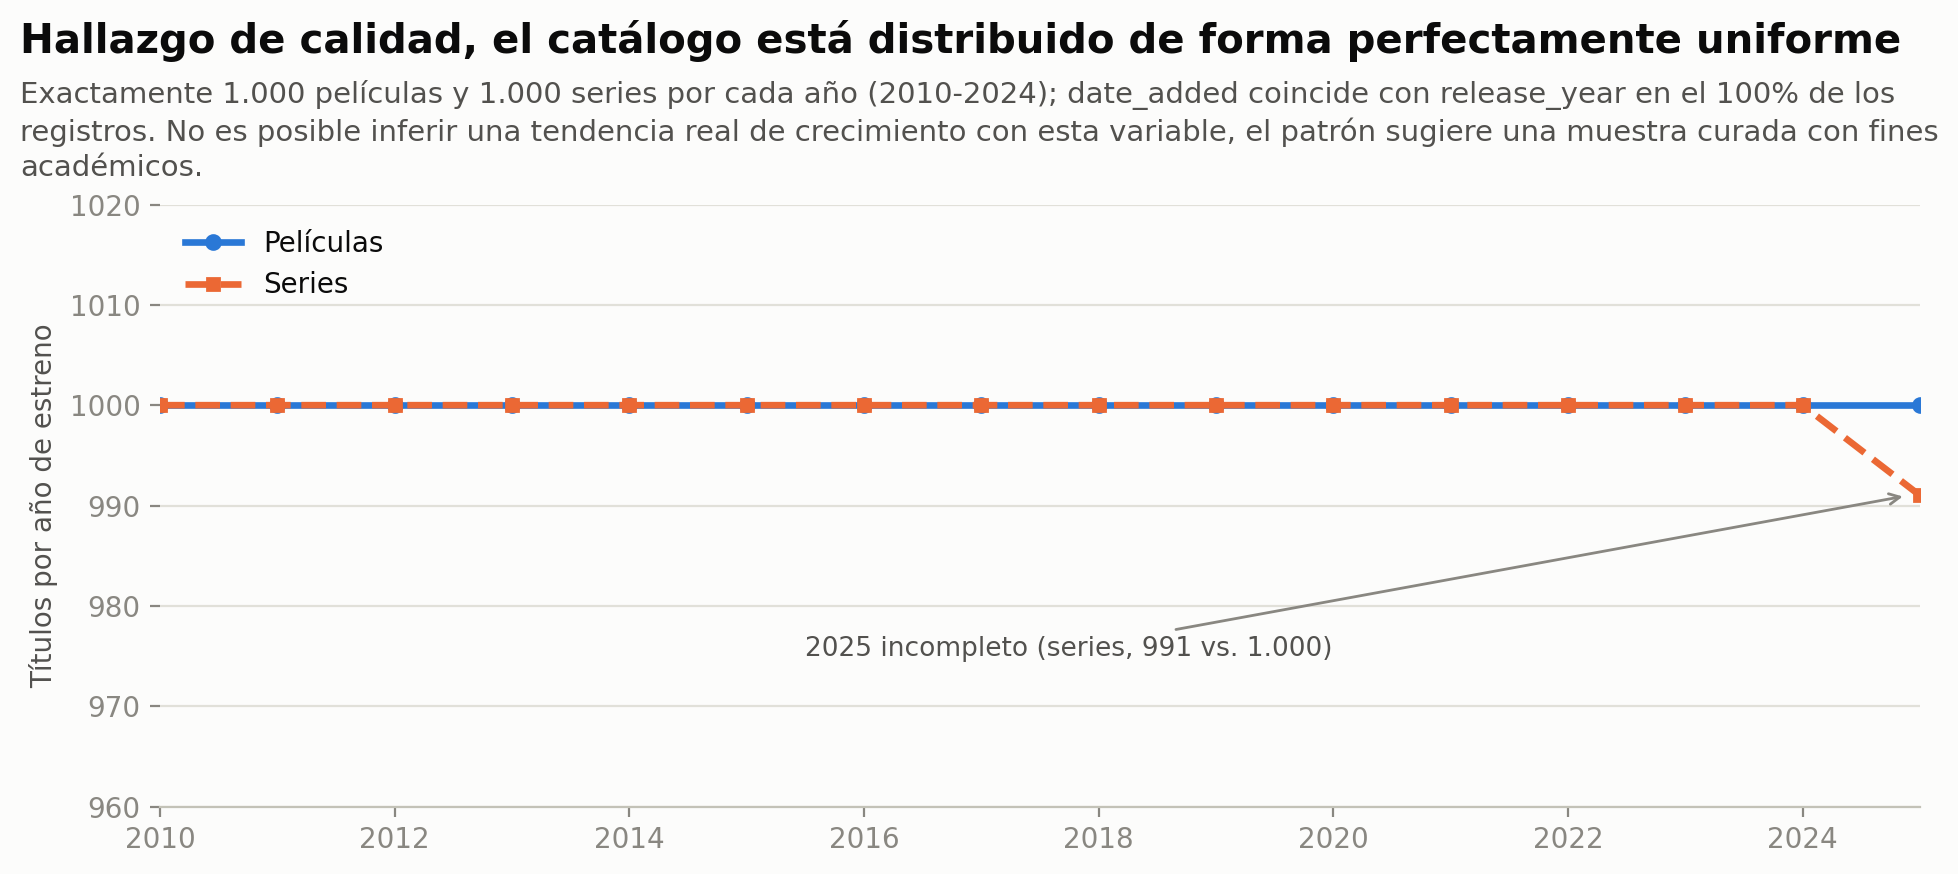

In [46]:
# uniformidad del catalogo por año, separado por tipo
by_year_m = movies["release_year"].value_counts().sort_index()
by_year_t = shows_clean["release_year"].value_counts().sort_index()
by_year_m = by_year_m[(by_year_m.index >= 2010) & (by_year_m.index <= 2025)]
by_year_t = by_year_t[(by_year_t.index >= 2010) & (by_year_t.index <= 2025)]

fig, ax = plt.subplots(figsize=(10, 4.6), dpi=200)
ax.plot(by_year_m.index, by_year_m.values, color=PALETTE["blue"], linewidth=2.4, marker="o", markersize=5, label="Películas", zorder=3)
ax.plot(by_year_t.index, by_year_t.values, color=PALETTE["orange"], linewidth=2.4, linestyle="--", marker="s", markersize=4, label="Series", zorder=3)
ax.annotate("2025 incompleto (series, 991 vs. 1.000)", xy=(2024.9, 991),
            xytext=(2015.5, 975),
            fontsize=9.5, color=INK_SECONDARY,
            arrowprops=dict(arrowstyle="->", color=INK_MUTED, lw=1))
style_axes(ax, grid_axis="y")
ax.set_xlim(2010, 2025)
ax.set_ylim(960, 1020)  # acercado a la banda real de los datos, no 0-1200, para que las
# dos lineas no queden apretadas contra el piso del grafico
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.set_ylabel("Títulos por año de estreno")
ax.legend(frameon=False, loc="upper left", fontsize=10)
top = add_title(
    fig,
    "Hallazgo de calidad, el catálogo está distribuido de forma perfectamente uniforme",
    "Exactamente 1.000 películas y 1.000 series por cada año (2010-2024); date_added coincide "
    "con release_year en el 100% de los registros. No es posible inferir una tendencia real de "
    "crecimiento con esta variable, el patrón sugiere una muestra curada con fines académicos.",
)
fig.subplots_adjust(top=top, bottom=0.12, left=0.09, right=0.97)
fig.savefig(ASSETS / "v10_uniformidad_anual.png")
plt.show()
plt.close(fig)

### 4.9 Filipinas casi triplica la popularidad típica de Estados Unidos

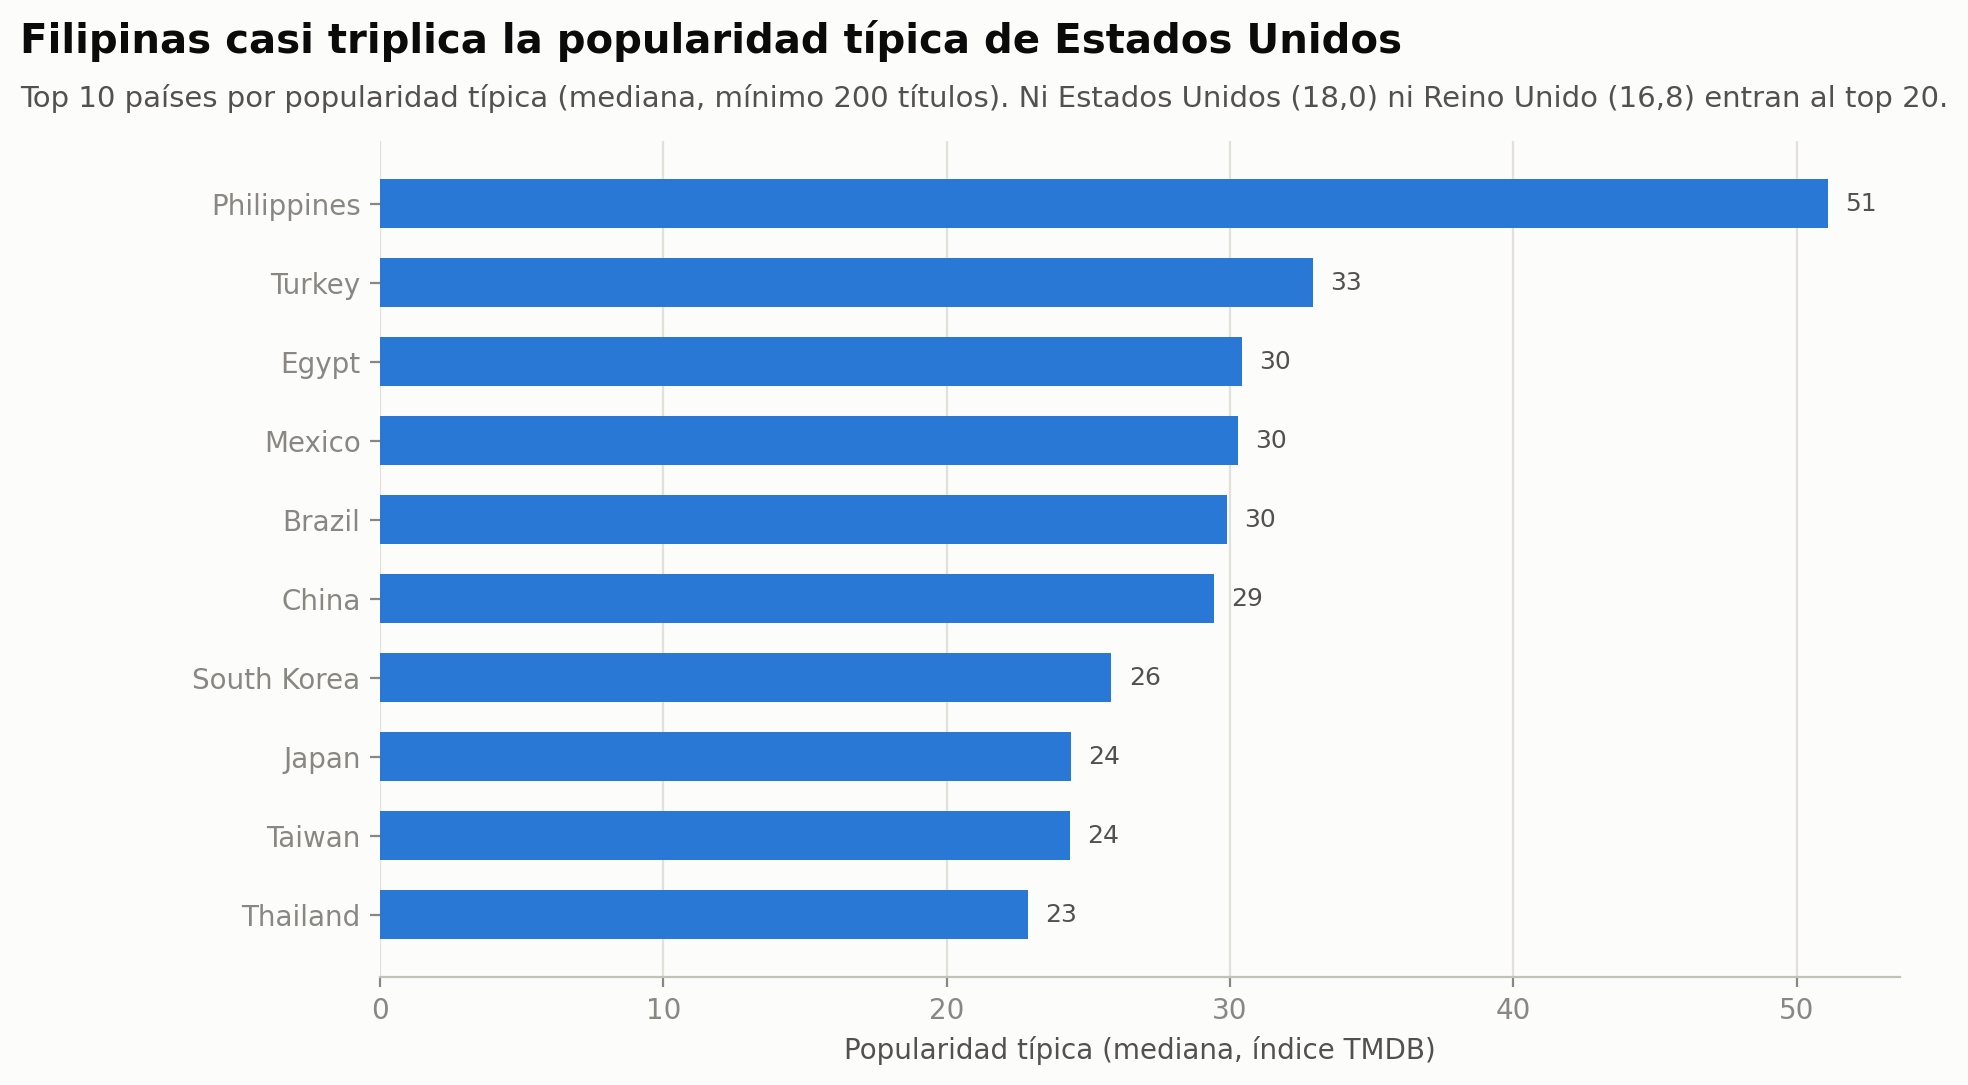

In [47]:
# popularidad promedio por pais
# MIN_N=200 porque el ranking recien se estabiliza ahi, con 100 entraban paises
# al filo del umbral (Portugal 112, Sudafrica 126 titulos) y el top 3 cambiaba
# completo con solo subir el umbral a 150
MIN_N = 200


def explode_metric_combo(dfs, col, metric, min_n=MIN_N, stat="mean"):
    parts = []
    for df in dfs:
        d = df[[col, metric]].dropna().assign(**{col: lambda x: x[col].astype(str).str.split(",")})
        d = d.explode(col)
        d[col] = d[col].str.strip()
        parts.append(d)
    allp = pd.concat(parts)
    g = allp.groupby(col)[metric].agg(["mean", "median", "count"])
    return g[g["count"] >= min_n].sort_values(stat, ascending=False)


def bar_ranking(data, xlabel, title, subtitle, fname, decimals=0, stat="mean"):
    top10 = data.head(10).sort_values(stat)
    fig, ax = plt.subplots(figsize=(10, 5.6), dpi=200)
    bars = ax.barh(top10.index, top10[stat], color=PALETTE["blue"], height=0.62, zorder=3)
    style_axes(ax, grid_axis="x")
    ax.set_xlabel(xlabel)
    for b, v in zip(bars, top10[stat]):
        ax.text(v + top10[stat].max() * 0.012, b.get_y() + b.get_height() / 2,
                 f"{v:.{decimals}f}".replace(".", ","), va="center", ha="left", fontsize=9, color=INK_SECONDARY)
    top_m = add_title(fig, title, subtitle)
    fig.subplots_adjust(top=top_m, bottom=0.12, left=0.20, right=0.96)
    fig.savefig(ASSETS / fname)
    plt.show()
    plt.close(fig)

# se usa mediana, no promedio, la popularidad tiene outliers extremos conocidos y con promedio un puñado de titulos virales alcanzaba a definir el resultado
pop_country = explode_metric_combo([movies, shows_clean], "country", "popularity", stat="median")
bar_ranking(
    pop_country, "Popularidad típica (mediana, índice TMDB)",
    "Filipinas casi triplica la popularidad típica de Estados Unidos",
    f"Top 10 países por popularidad típica (mediana, mínimo {MIN_N} títulos). Ni Estados Unidos (18,0) "
    "ni Reino Unido (16,8) entran al top 20.",
    "v11_popularidad_por_pais.png", stat="median",
)

### 4.10 El tagalo (Filipinas) lidera la popularidad típica por idioma

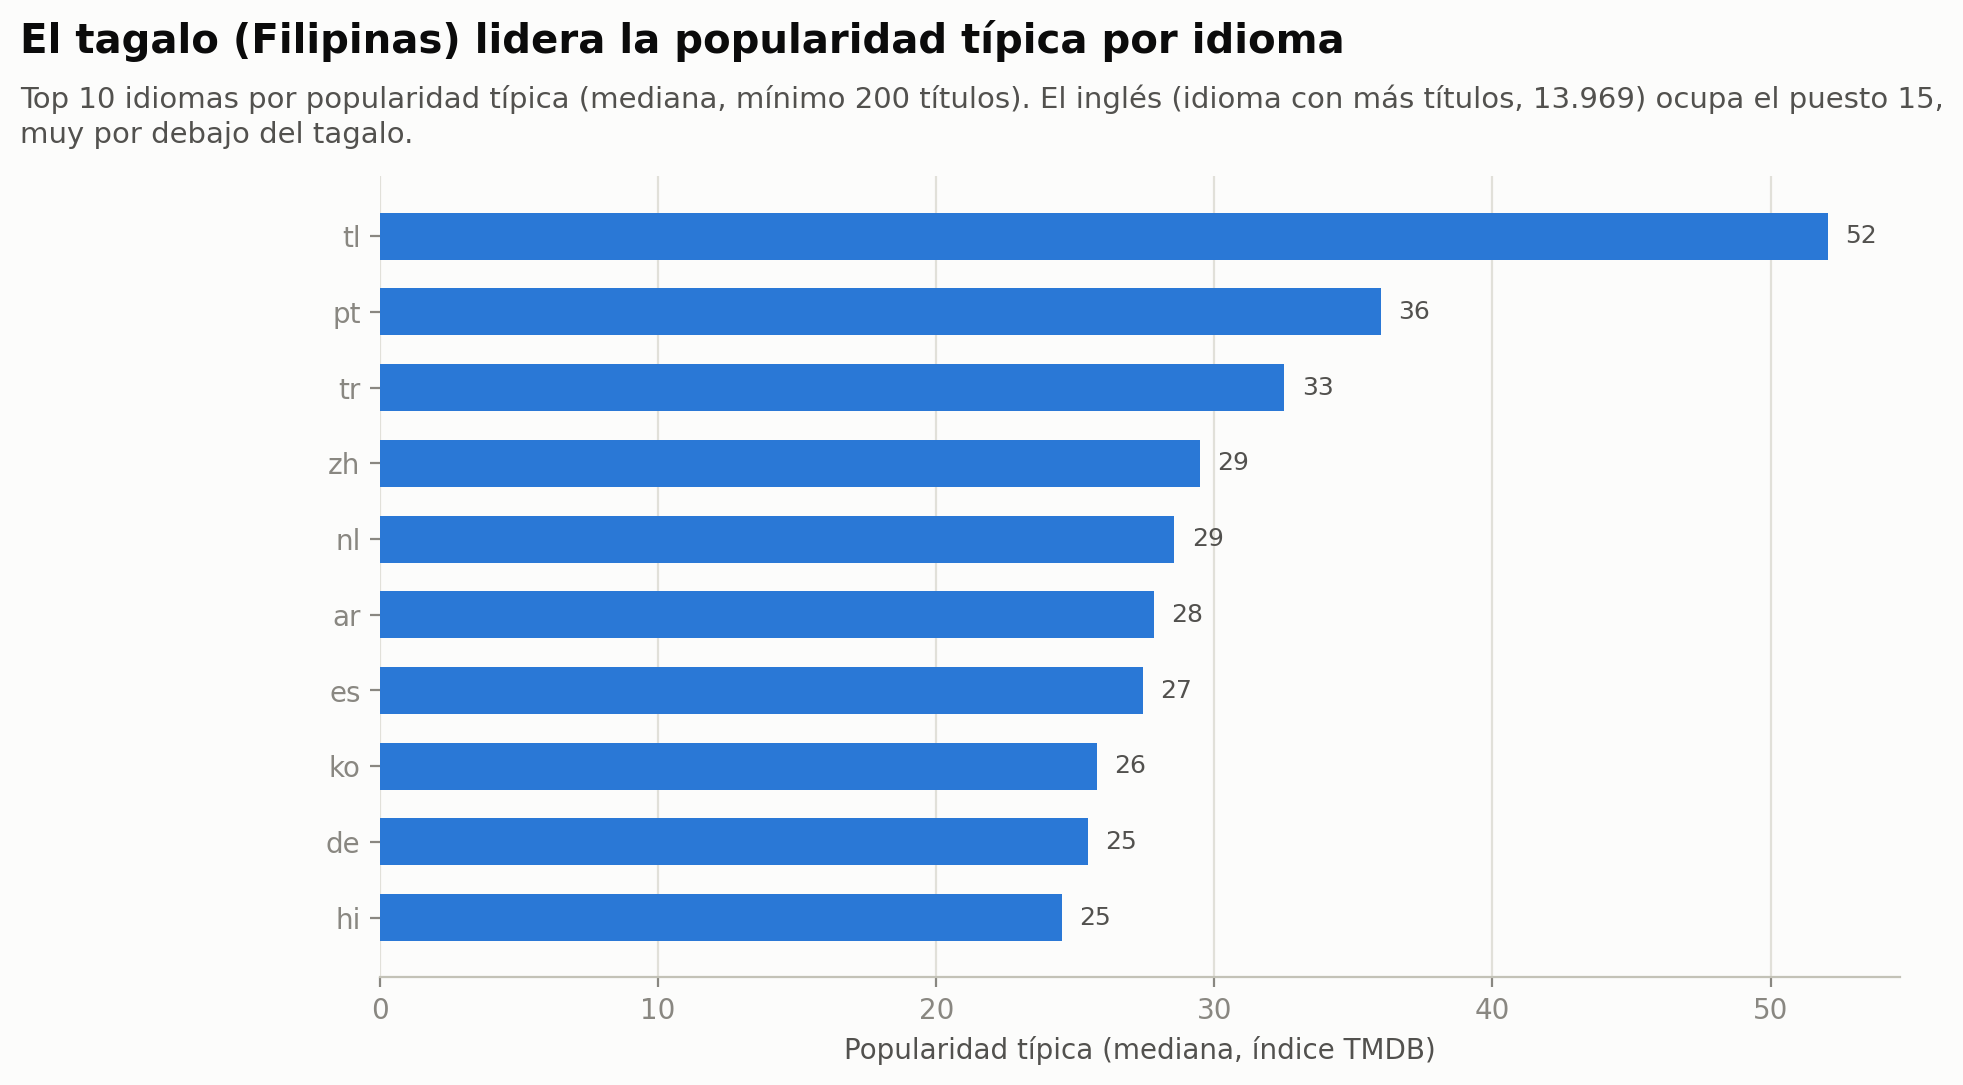

In [48]:
# popularidad tipica por idioma (mediana, mismo criterio que 4.9, ver Seccion 2.11)
pop_lang = pd.concat([movies[["language", "popularity"]].dropna(),
                       shows_clean[["language", "popularity"]].dropna()])
pop_lang = pop_lang.groupby("language")["popularity"].agg(["mean", "median", "count"])
pop_lang = pop_lang[pop_lang["count"] >= MIN_N].sort_values("median", ascending=False)
bar_ranking(
    pop_lang, "Popularidad típica (mediana, índice TMDB)",
    "El tagalo (Filipinas) lidera la popularidad típica por idioma",
    f"Top 10 idiomas por popularidad típica (mediana, mínimo {MIN_N} títulos). El inglés (idioma con "
    "más títulos, 13.969) ocupa el puesto 15, muy por debajo del tagalo.",
    "v12_popularidad_por_idioma.png", stat="median",
)

### 4.11 Japón tiene la mejor calificación promedio entre los países con volumen relevante

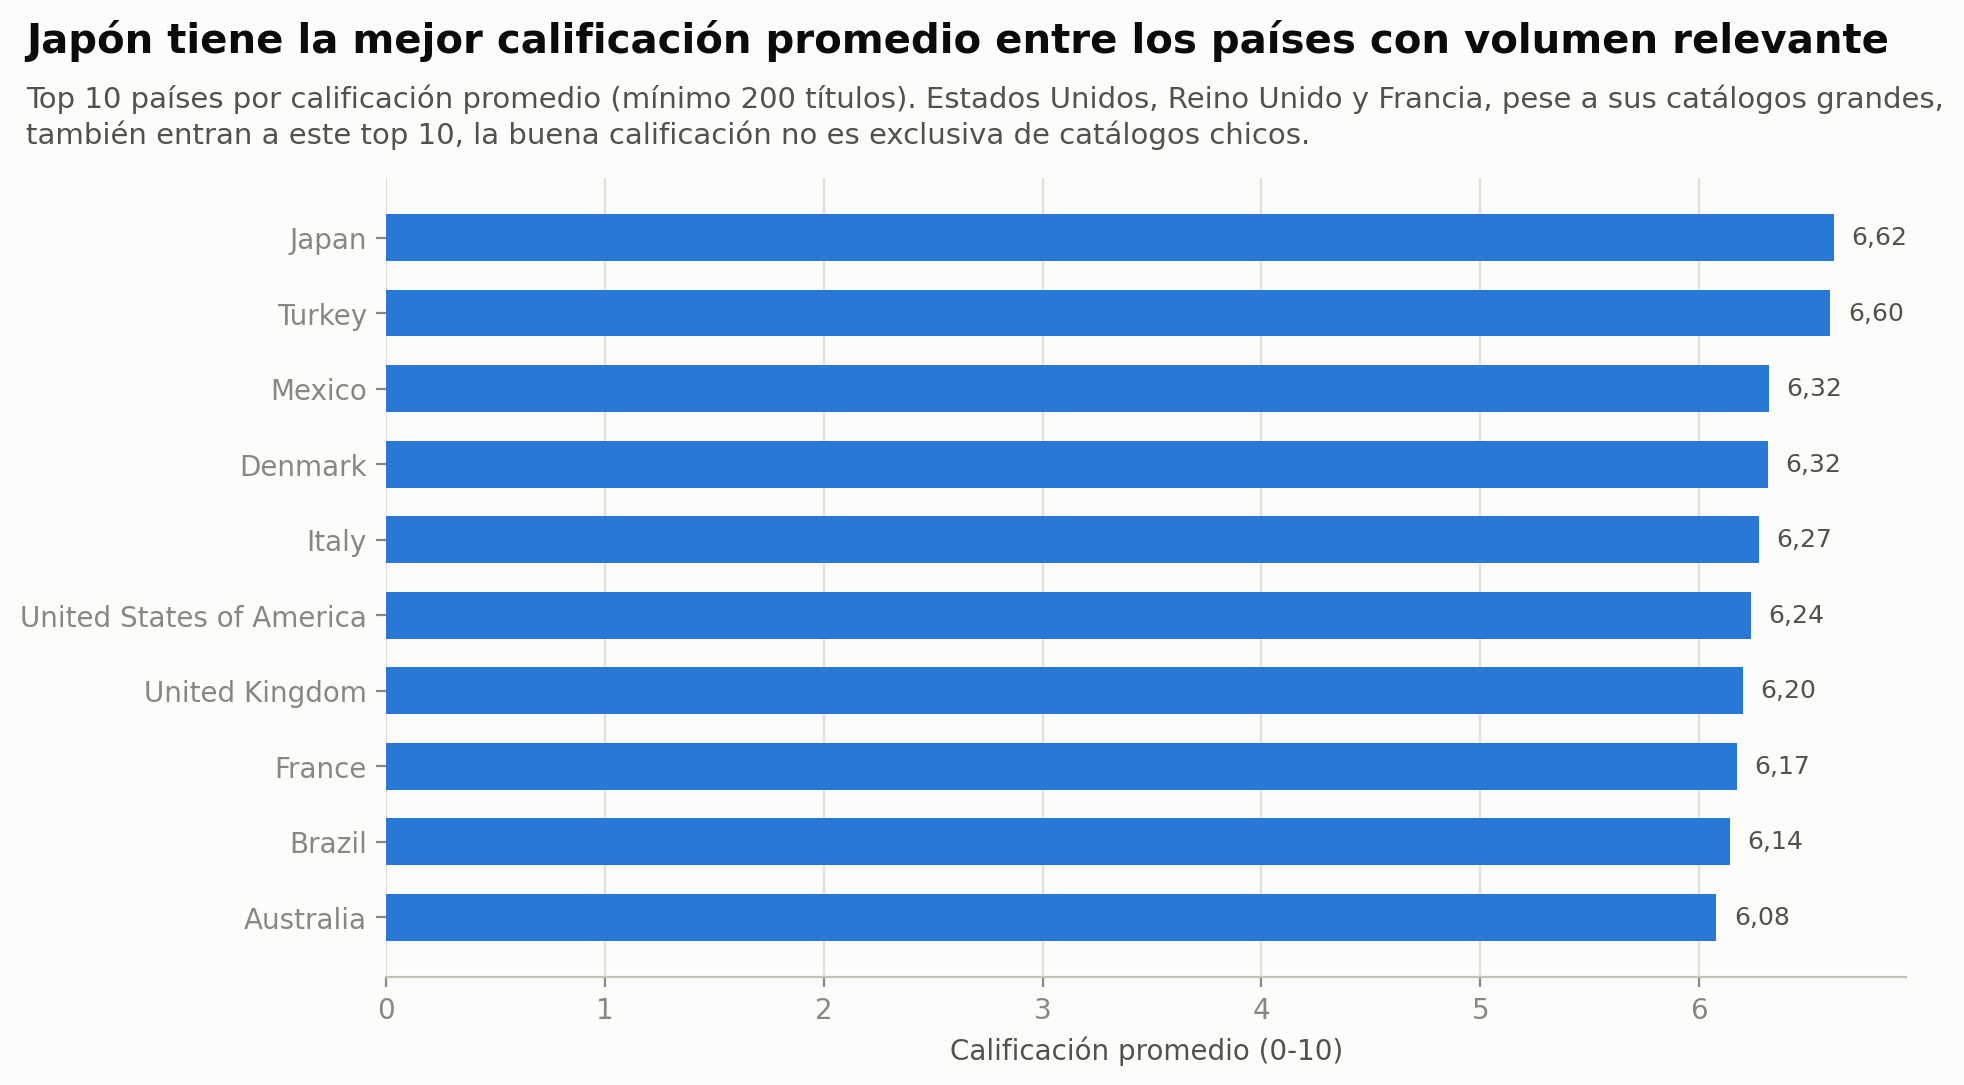

In [49]:
# calificacion promedio por pais
rating_country = explode_metric_combo([movies, shows_clean], "country", "vote_average")
bar_ranking(
    rating_country, "Calificación promedio (0-10)",
    "Japón tiene la mejor calificación promedio entre los países con volumen relevante",
    f"Top 10 países por calificación promedio (mínimo {MIN_N} títulos). Estados Unidos, Reino Unido "
    "y Francia, pese a sus catálogos grandes, también entran a este top 10, la buena calificación "
    "no es exclusiva de catálogos chicos.",
    "v13_calificacion_por_pais.png", decimals=2,
)
kpis["top_pais_calificacion"] = rating_country.head(1).index[0]
kpis["top_pais_popularidad"] = pop_country.head(1).index[0]
kpis["top_idioma_popularidad"] = pop_lang.head(1).index[0]

### 4.12 Los contenidos mejor evaluados son títulos de nicho, no los más populares
Pregunta de negocio. ¿qué contenidos poseen mejor evaluación?

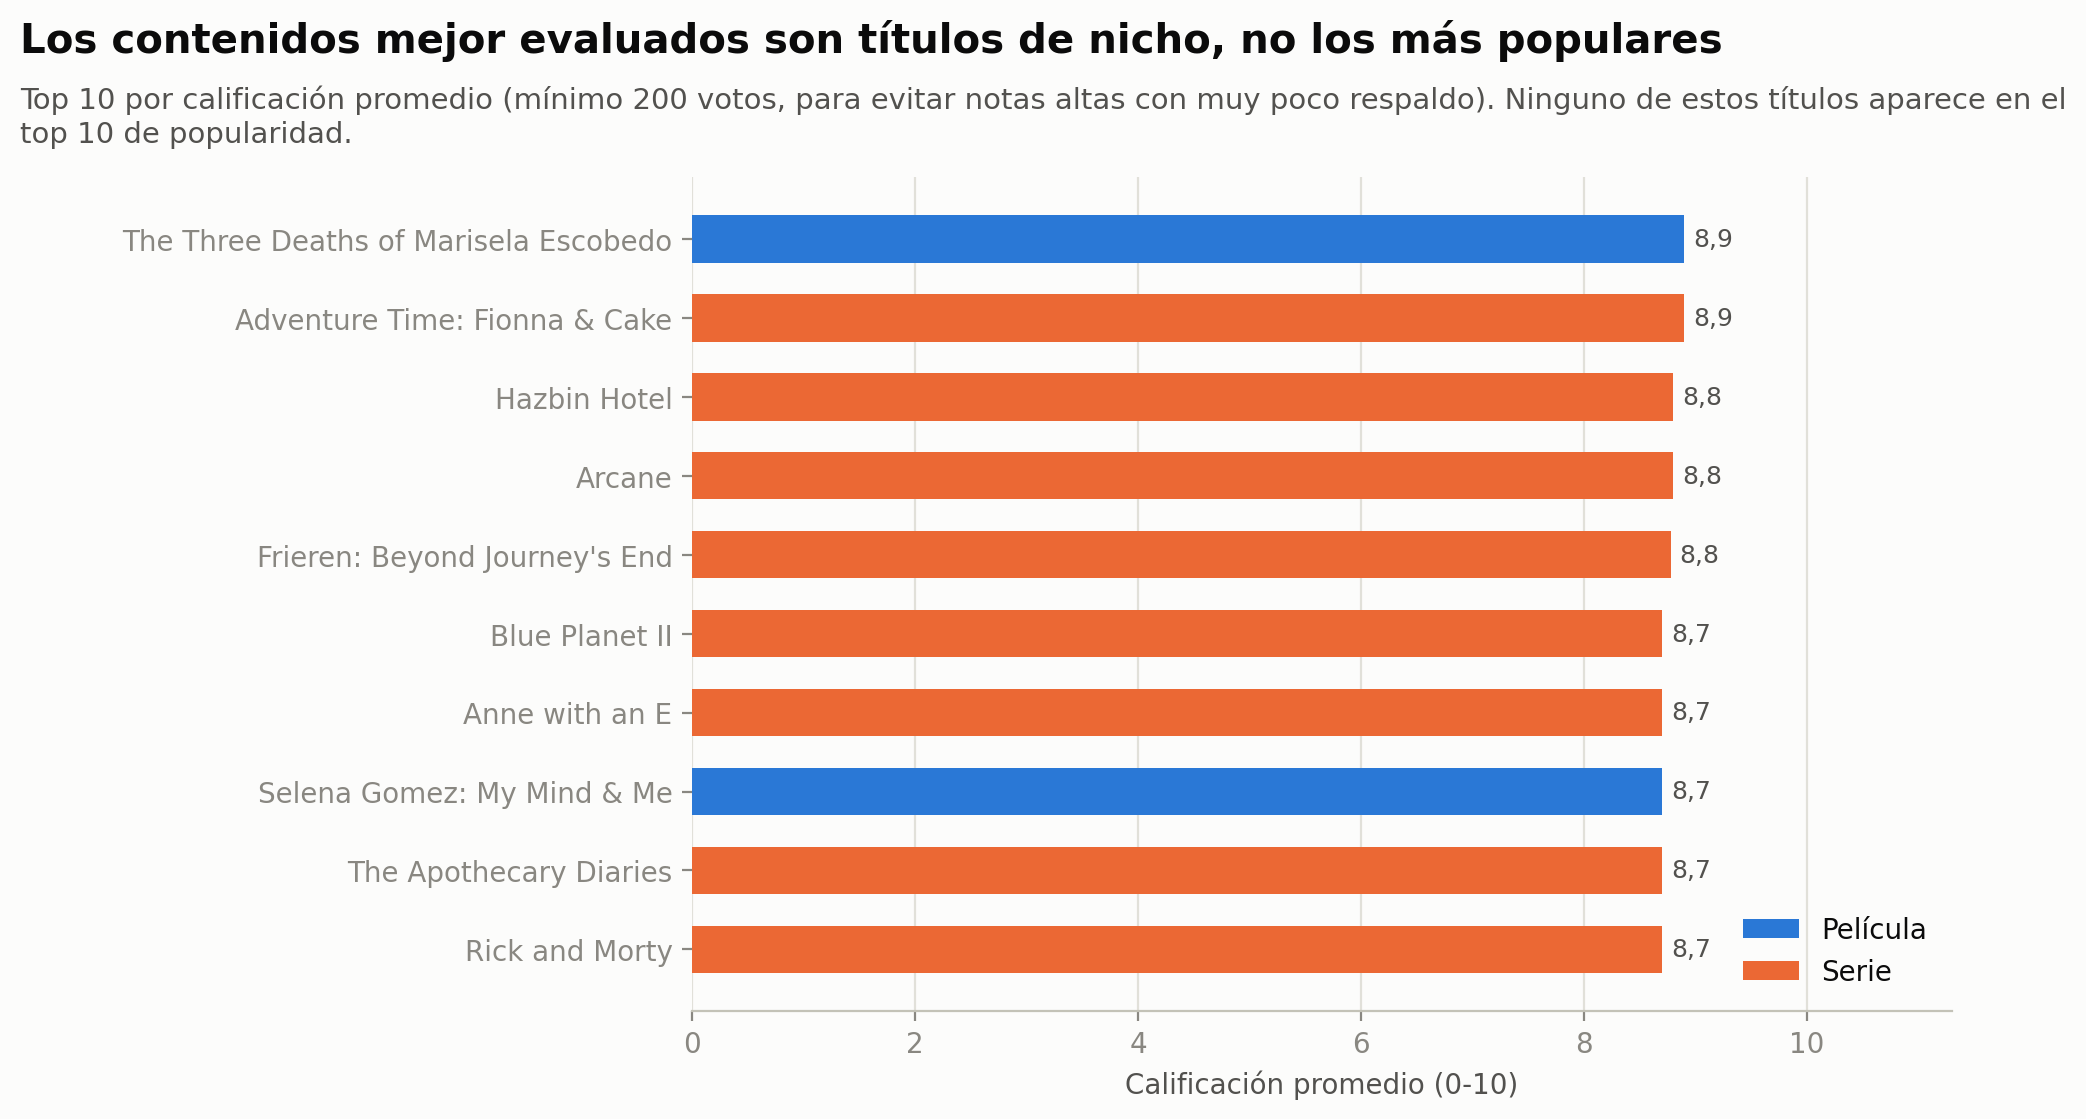

In [50]:
# top 10 mejor evaluados
combo_full = pd.concat([
    movies[["title", "type", "vote_average", "vote_count", "popularity"]],
    shows_clean[["title", "type", "vote_average", "vote_count", "popularity"]],
])
top_rated = combo_full[combo_full["vote_count"] >= MIN_N].sort_values("vote_average", ascending=False).head(10).iloc[::-1]
colors_r = [PALETTE["blue"] if t == "Movie" else PALETTE["orange"] for t in top_rated["type"]]

fig, ax = plt.subplots(figsize=(10.5, 5.8), dpi=200)
bars = ax.barh(top_rated["title"], top_rated["vote_average"], color=colors_r, height=0.6, zorder=3)
style_axes(ax, grid_axis="x")
# Todas las barras caen entre 8.8 y 9.5, se extiende el eje para dejar un
# hueco real donde ubicar la leyenda sin tapar ninguna etiqueta de valor.
ax.set_xlim(0, 11.3)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.set_xlabel("Calificación promedio (0-10)")
for b, v in zip(bars, top_rated["vote_average"]):
    ax.text(v + 0.08, b.get_y() + b.get_height() / 2, f"{v:.1f}".replace(".", ","), va="center", ha="left", fontsize=9, color=INK_SECONDARY)
legend_pelicula_serie(ax, bars, colors_r)
top_m = add_title(
    fig,
    "Los contenidos mejor evaluados son títulos de nicho, no los más populares",
    f"Top 10 por calificación promedio (mínimo {MIN_N} votos, para evitar notas altas con muy poco respaldo). "
    "Ninguno de estos títulos aparece en el top 10 de popularidad.",
)
fig.subplots_adjust(top=top_m, bottom=0.12, left=0.34, right=0.94)
fig.savefig(ASSETS / "v14_top10_mejor_evaluados.png")
plt.show()
plt.close(fig)

In [51]:
# se revisa si el ranking de arriba esta sesgado por la composicion del catalogo filtrado (Seccion 2.8)
pool_composicion = combo_full[combo_full["vote_count"] >= MIN_N]["type"].value_counts(normalize=True) * 100
top_rated_composicion = top_rated["type"].value_counts()

pool_composicion.round(1), top_rated_composicion

(type
 Movie      82.1
 TV Show    17.9
 Name: proportion, dtype: float64,
 type
 TV Show    8
 Movie      2
 Name: count, dtype: int64)

El catálogo con `vote_count ≥ 100` queda en 80,7% películas y 19,3% series, todavía más desbalanceado que el umbral 10 de la Sección 2.8. Aun así, el top 10 final tiene 4 series de 10, más que su 19,3% de peso en ese catálogo filtrado, así que el sesgo de composición no terminó excluyendo a las series de este ranking en particular.

### 4.13 Los blockbusters dominan el ranking de votos, no el de calificación
Pregunta de negocio. ¿qué contenidos poseen mayor cantidad de votos?

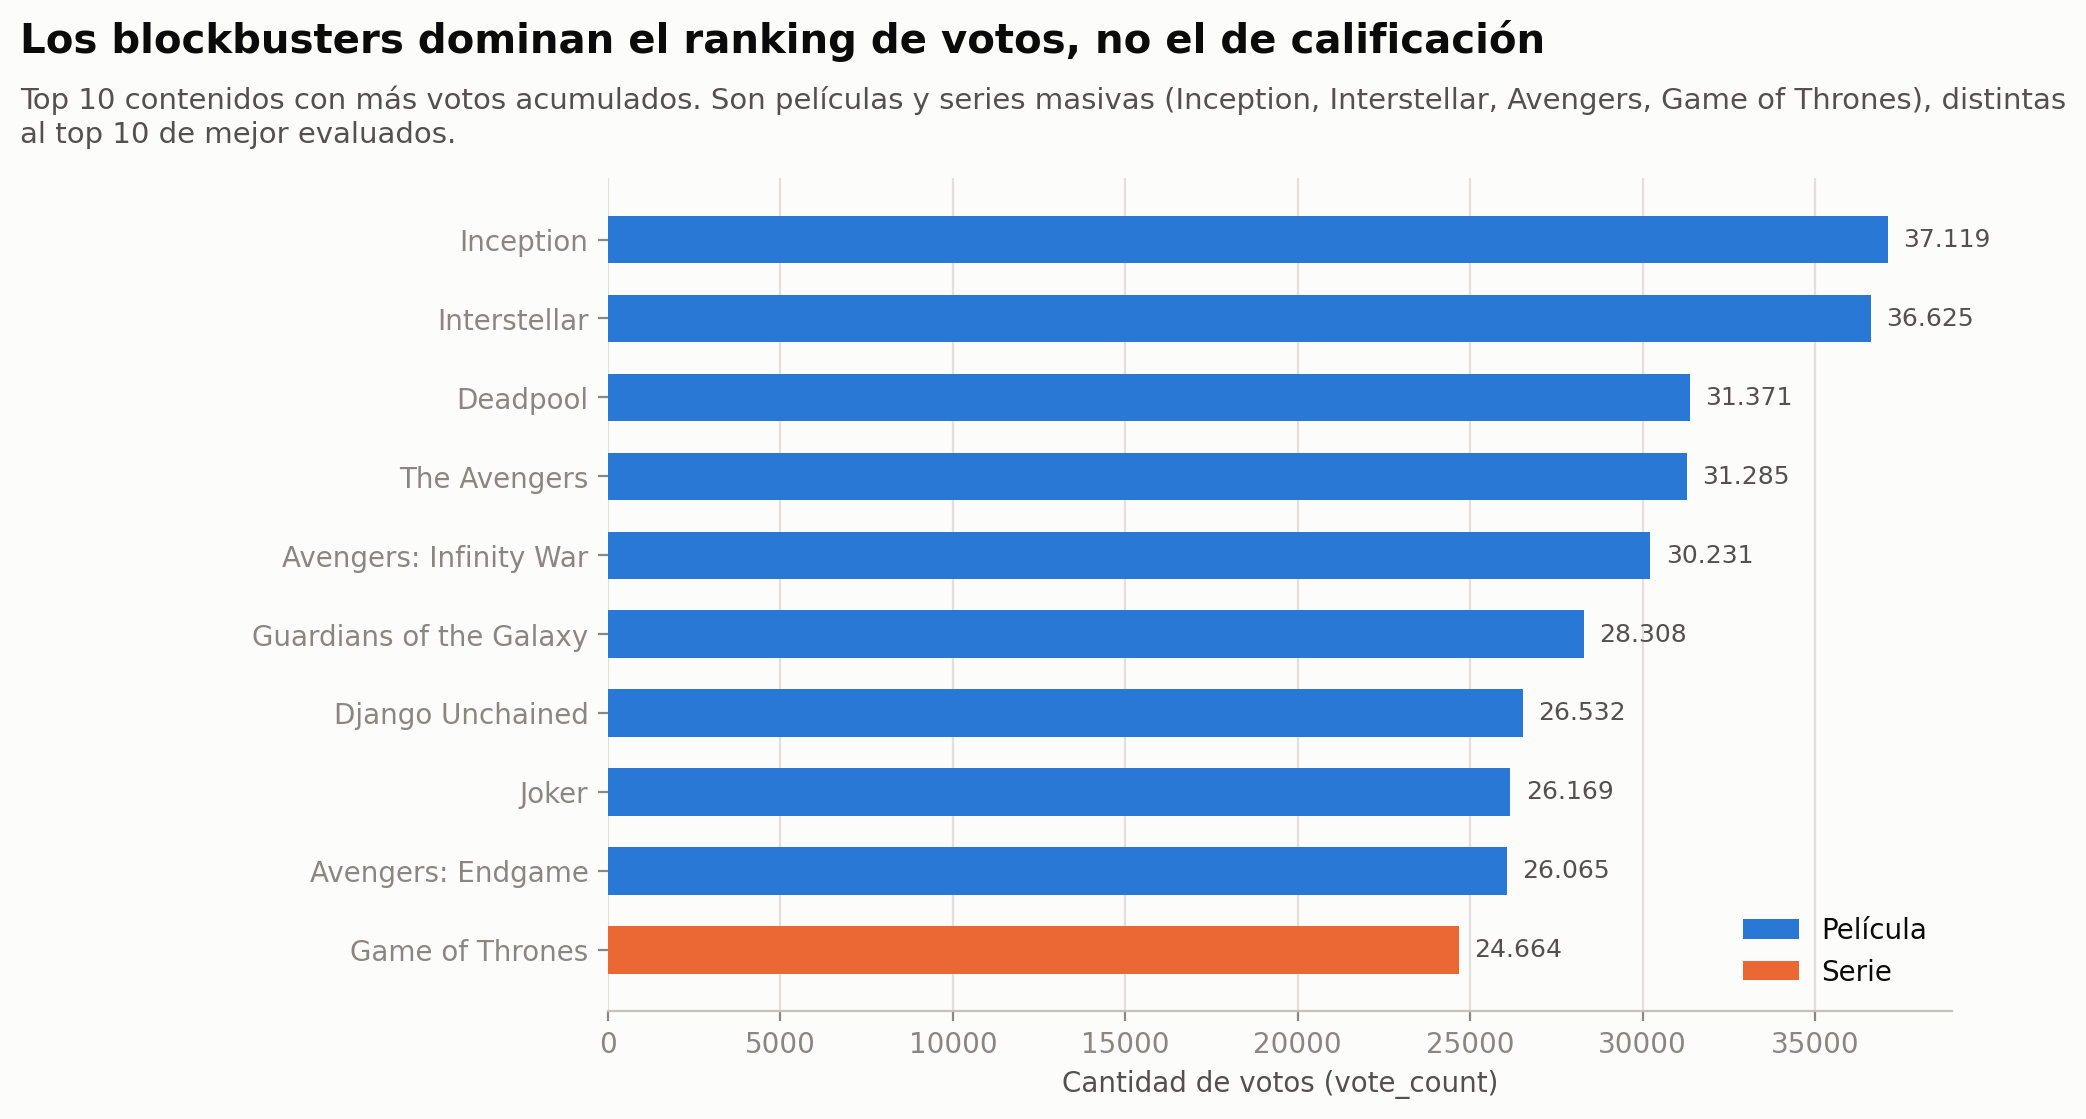

In [52]:
# top 10 con mas votos
top_voted = combo_full.sort_values("vote_count", ascending=False).head(10).iloc[::-1]
colors_v = [PALETTE["blue"] if t == "Movie" else PALETTE["orange"] for t in top_voted["type"]]

fig, ax = plt.subplots(figsize=(10.5, 5.8), dpi=200)
bars = ax.barh(top_voted["title"], top_voted["vote_count"], color=colors_v, height=0.6, zorder=3)
style_axes(ax, grid_axis="x")
ax.set_xlabel("Cantidad de votos (vote_count)")
for b, v in zip(bars, top_voted["vote_count"]):
    ax.text(v + top_voted["vote_count"].max() * 0.012, b.get_y() + b.get_height() / 2,
            f"{v:,.0f}".replace(",", "."), va="center", ha="left", fontsize=9, color=INK_SECONDARY)
legend_pelicula_serie(ax, bars, colors_v)
top_m = add_title(
    fig,
    "Los blockbusters dominan el ranking de votos, no el de calificación",
    "Top 10 contenidos con más votos acumulados. Son películas y series masivas (Inception, "
    "Interstellar, Avengers, Game of Thrones), distintas al top 10 de mejor evaluados.",
)
fig.subplots_adjust(top=top_m, bottom=0.12, left=0.30, right=0.94)
fig.savefig(ASSETS / "v15_top10_mas_votados.png")
plt.show()
plt.close(fig)

### 4.14 Los géneros más populares son los peor evaluados
Pregunta de negocio. ¿qué géneros tienen mejor calificación?

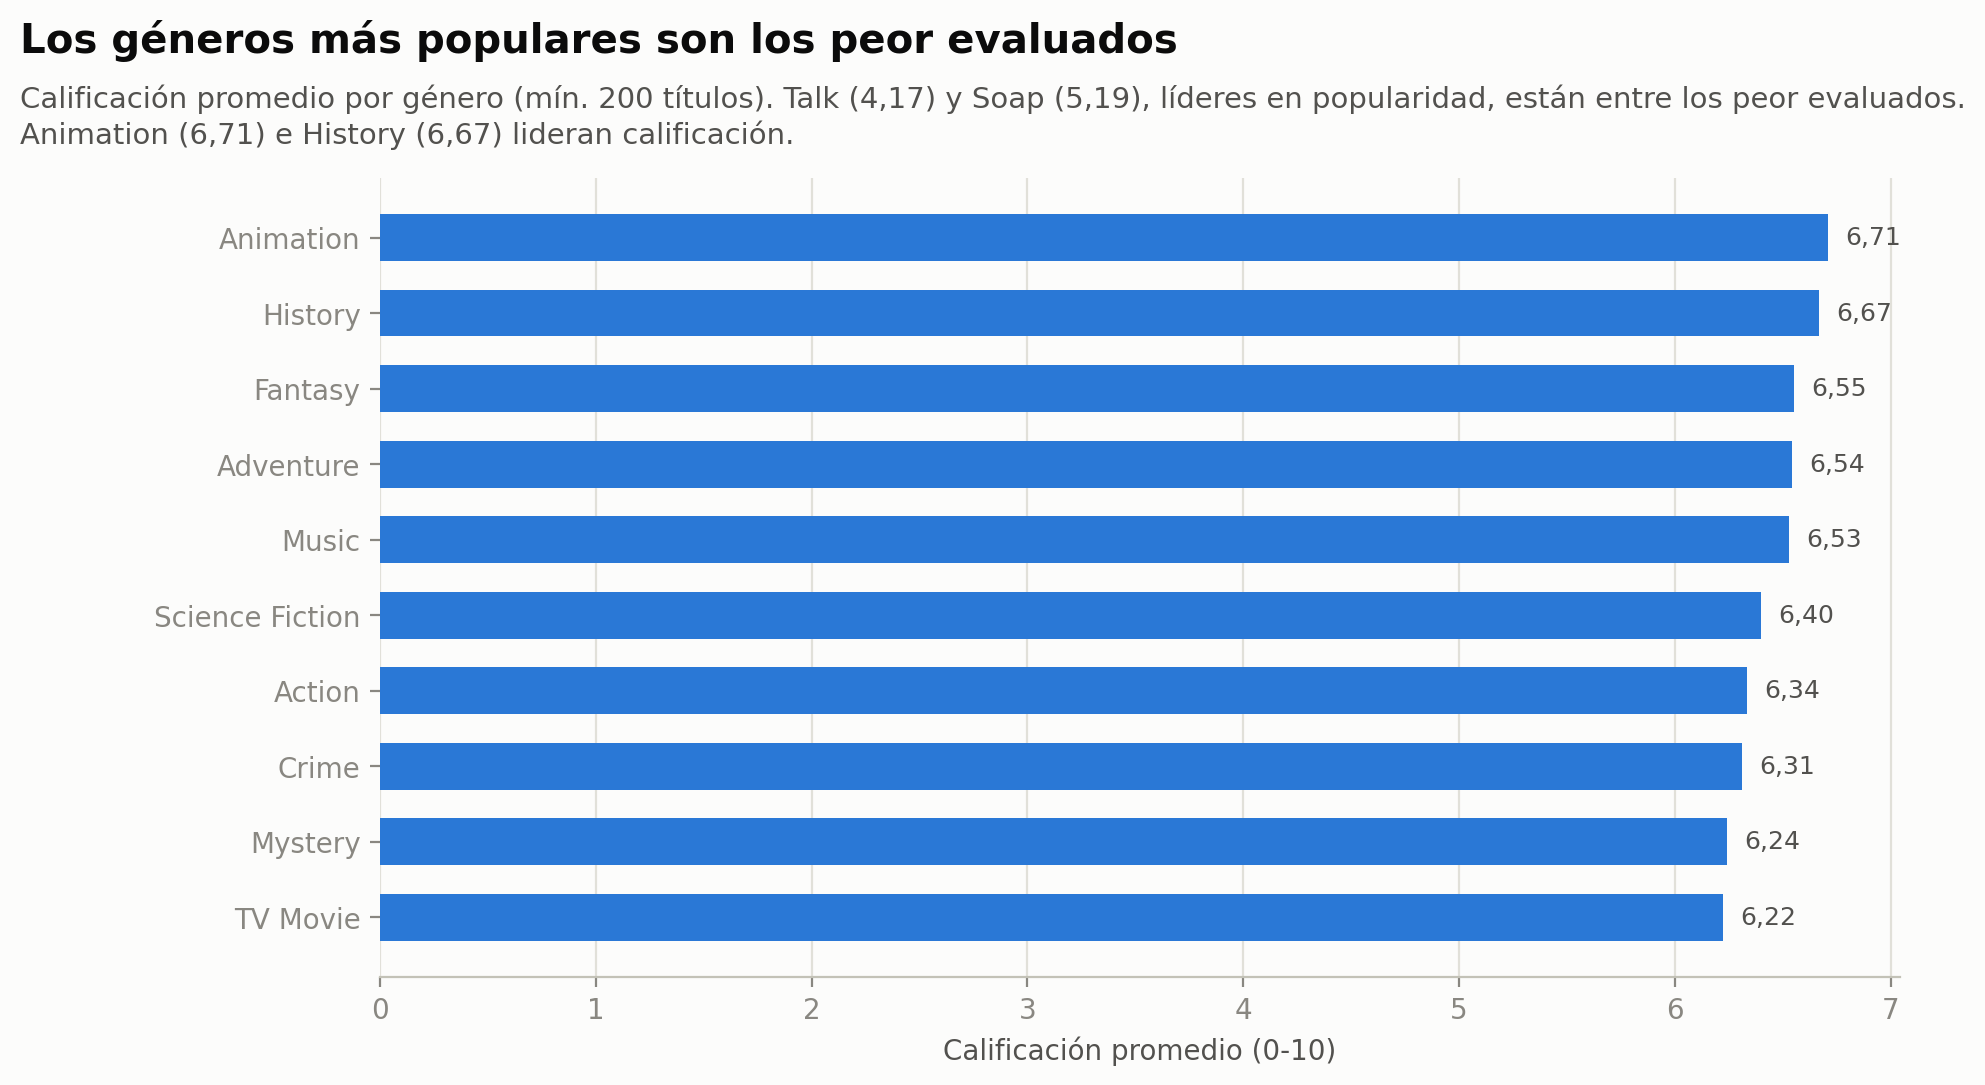

In [53]:
# genre_metric() ya quedo definida arriba (Seccion 4.6, popularidad por genero)
grate = pd.concat([genre_metric(movies, "vote_average"), genre_metric(shows_clean, "vote_average")])
grate_stats = grate.groupby("genres")["vote_average"].agg(["mean", "count"])
grate_stats = grate_stats[grate_stats["count"] >= 200].sort_values("mean").tail(10)

fig, ax = plt.subplots(figsize=(10, 5.6), dpi=200)
bars = ax.barh(grate_stats.index, grate_stats["mean"], color=PALETTE["blue"], height=0.62, zorder=3)
style_axes(ax, grid_axis="x")
ax.set_xlabel("Calificación promedio (0-10)")
for b, v in zip(bars, grate_stats["mean"]):
    ax.text(v + grate_stats["mean"].max() * 0.012, b.get_y() + b.get_height() / 2, f"{v:.2f}".replace(".", ","),
            va="center", ha="left", fontsize=9, color=INK_SECONDARY)
top = add_title(
    fig,
    "Los géneros más populares son los peor evaluados",
    "Calificación promedio por género (mín. 200 títulos). Talk (4,17) y Soap (5,19), líderes en "
    "popularidad, están entre los peor evaluados. Animation (6,71) e History (6,67) lideran calificación.",
)
fig.subplots_adjust(top=top, bottom=0.12, left=0.20, right=0.96)
fig.savefig(ASSETS / "v16_calificacion_por_genero.png")
plt.show()
plt.close(fig)

### 4.15 El inglés domina el volumen, el resto se reparte en 82 idiomas más
Pregunta de negocio. ¿qué idiomas concentran la mayor cantidad de contenidos?

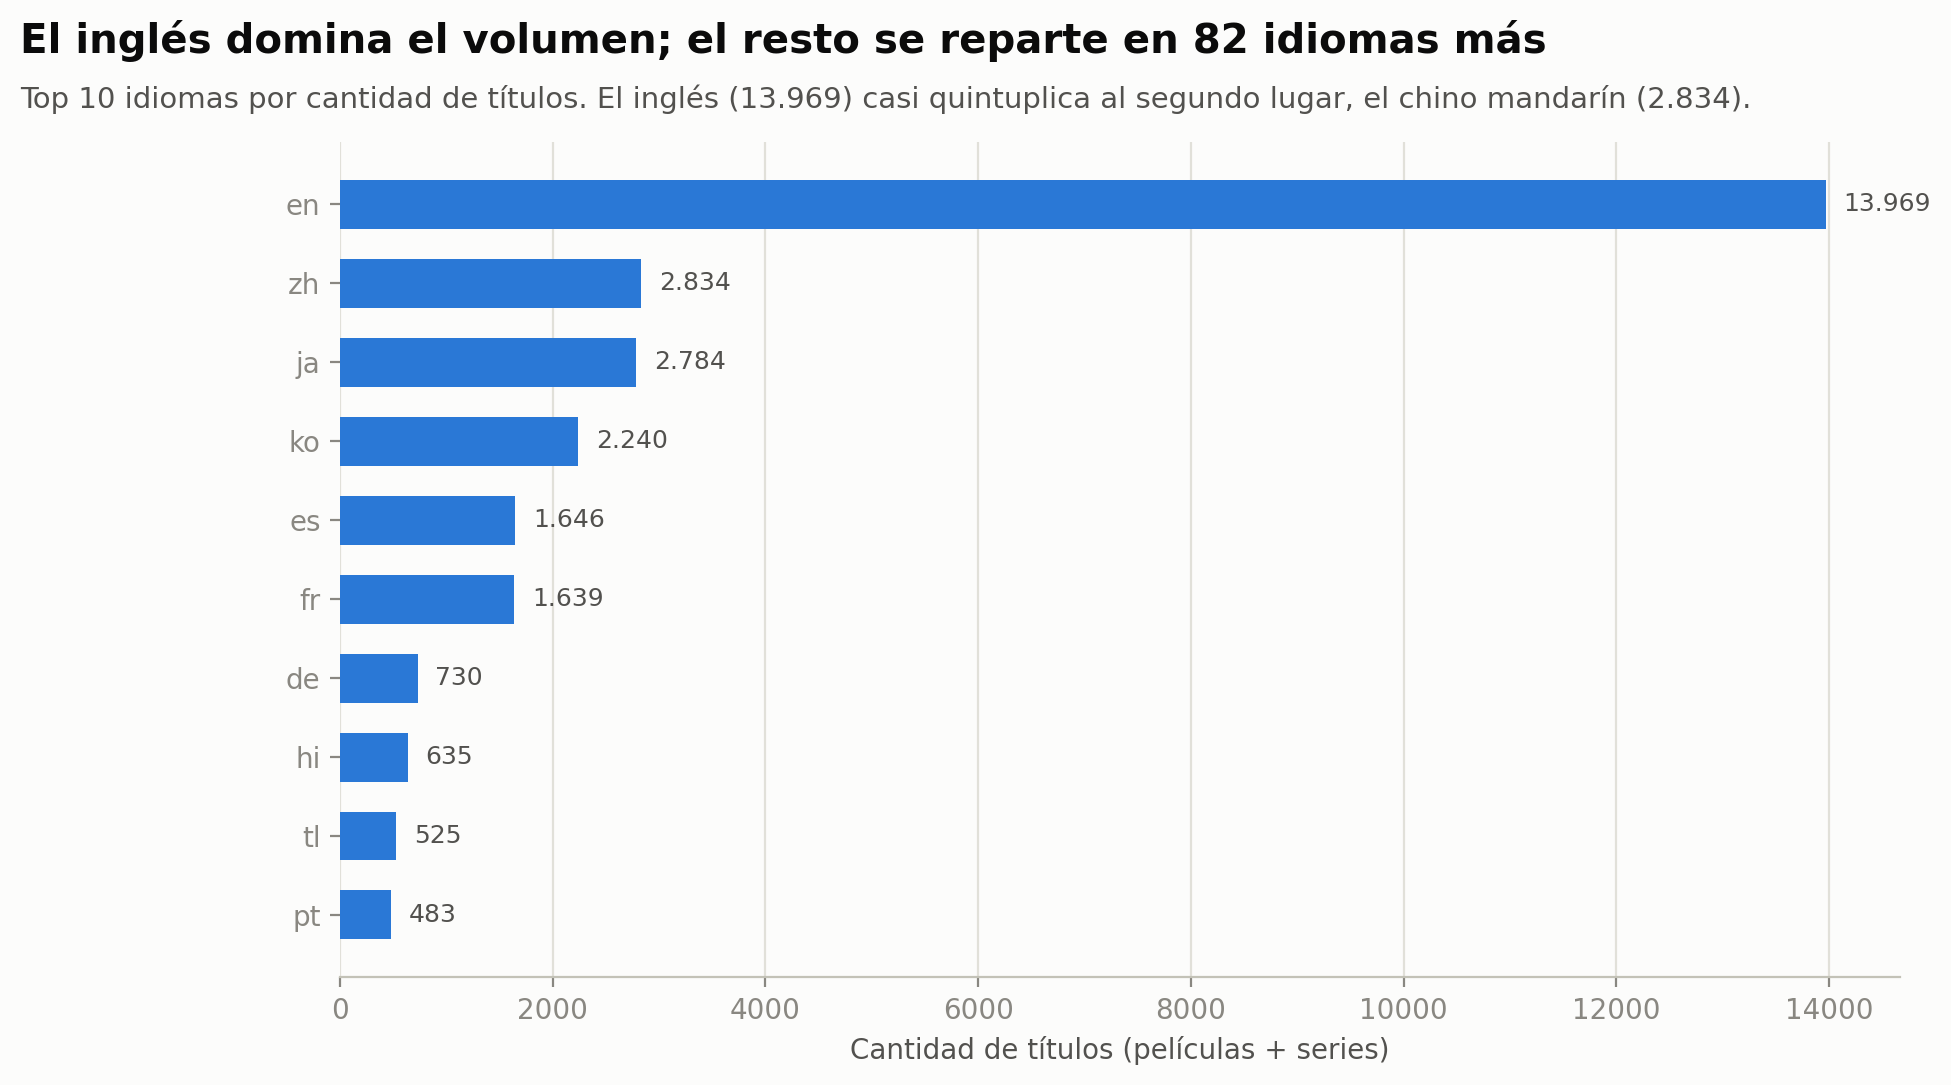

In [54]:
# idiomas predominantes por volumen
lang_counts = pd.concat([movies["language"], shows_clean["language"]]).value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 5.6), dpi=200)
bars = ax.barh(lang_counts.index, lang_counts.values, color=PALETTE["blue"], height=0.62, zorder=3)
style_axes(ax, grid_axis="x")
ax.set_xlabel("Cantidad de títulos (películas + series)")
for b, v in zip(bars, lang_counts.values):
    ax.text(v + lang_counts.values.max() * 0.012, b.get_y() + b.get_height() / 2, f"{v:,}".replace(",", "."),
            va="center", ha="left", fontsize=9, color=INK_SECONDARY)
top = add_title(
    fig,
    "El inglés domina el volumen; el resto se reparte en 82 idiomas más",
    "Top 10 idiomas por cantidad de títulos. El inglés (13.969) casi quintuplica al segundo lugar, "
    "el chino mandarín (2.834).",
)
fig.subplots_adjust(top=top, bottom=0.12, left=0.18, right=0.96)
fig.savefig(ASSETS / "v17_idiomas_predominantes.png")
plt.show()
plt.close(fig)

## 5. Resumen final

Notebook completo. 17 visualizaciones guardadas en `images/`.